# Week 5 — Experiment 02: First-Conduction GP Kernel Comparison

This notebook compares four Gaussian Process regression kernels on two simulation-level datasets:

- **Clean:** 91 simulations with Conduction and no Screenshot Bug anywhere.
- **Broad:** 238 simulations with an observed Conduction frame, including bug-affected sequences.

The response is the **first observed Conduction timestep**. It is a raw simulation timestep number, not physical time. Persistent onset and observational ambiguity intervals remain diagnostics and are not used as regression targets here.


## 1. Fixed scientific scope

One row means one `name` simulation. The inputs are exactly `P`, `VX`, `LS`, and `ST`. The three never-Conduction simulations are excluded because their point target is undefined. The broad analysis uses the first Conduction timestep actually observed, without interpolation, midpoint substitution, a censored likelihood, or a learned noise term.

This is a GP regression warm-up. It is not active learning, level-set estimation, survival analysis, or an optimizer-family comparison.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import subprocess
import time
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, RBF
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPOSITORY_ROOT = find_repository_root()
AUDIT_PATH = REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "simulation_level_audit.csv"
PHASE1_SUMMARY_PATH = REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "data_audit_summary.json"
RAW_CSV_PATH = REPOSITORY_ROOT / "data" / "raw" / "sph_dataset" / "final-labels_all.csv"
OUTPUT_ROOT = REPOSITORY_ROOT / "outputs" / "week5_02_first_conduction_gp_kernel_comparison"
CLEAN_DIR = OUTPUT_ROOT / "clean"
BROAD_DIR = OUTPUT_ROOT / "broad"
SAME_CLEAN_DIR = OUTPUT_ROOT / "same_clean_points"
COMBINED_DIR = OUTPUT_ROOT / "combined"
THESIS_LOG_PATH = REPOSITORY_ROOT / "docs" / "week5_first_conduction_gp_log.md"
for directory in [CLEAN_DIR, BROAD_DIR, SAME_CLEAN_DIR, COMBINED_DIR, THESIS_LOG_PATH.parent]:
    directory.mkdir(parents=True, exist_ok=True)

INPUT_COLUMNS = ["P", "VX", "LS", "ST"]
TARGET_COLUMN = "first_observed_conduction_timestep"
GROUP_COLUMN = "name"
EXPECTED_CLEAN_SIZE = 91
EXPECTED_BROAD_SIZE = 238
EXPECTED_NEVER_CONDUCTION = 3
RANDOM_SEED = 20260721
ALPHA_JITTER = 1e-6
OPTIMIZER = "fmin_l_bfgs_b"
N_RESTARTS_OPTIMIZER = 1
CONSTANT_INITIAL_VALUE = 1.0
CONSTANT_BOUNDS = (1e-3, 1e3)
LENGTHSCALE_INITIAL_VALUE = 1.0
LENGTHSCALE_BOUNDS = (1e-2, 1e2)
NORMALIZE_Y = True
INTERVAL_Z = 1.959963984540054
CSV_SHA256_EXPECTED = "964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154"
HF_REPOSITORY_ID = "ioandanielc/sph_dataset"
HF_FILENAME = "final-labels_all.csv"
HF_REVISION = "0e859b748fdbc8454f66e58e101e333ac0479d42"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 5)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

environment_summary = pd.DataFrame(
    {
        "item": [
            "Python", "scikit-learn", "pandas", "NumPy", "repository root",
            "audit artifact", "output root", "random seed", "execution date",
        ],
        "value": [
            platform.python_version(), sklearn.__version__, pd.__version__, np.__version__,
            str(REPOSITORY_ROOT), str(AUDIT_PATH), str(OUTPUT_ROOT), RANDOM_SEED,
            date.today().isoformat(),
        ],
    }
)
display(environment_summary)


,item,value
0,Python,3.12.13
1,scikit-learn,1.9.0
2,pandas,2.3.3
3,NumPy,2.5.1
4,repository root,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp
5,audit artifact,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\outputs\week5_01_first_conduction_data_audit\simulation_le...
6,output root,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\outputs\week5_02_first_conduction_gp_kernel_comparison
7,random seed,20260721
8,execution date,2026-07-21


**Interpretation.** All paths and numerical settings are declared before modelling. The same seed, optimizer, jitter, bounds, and restart count will be used for every kernel and every fold. This makes differences attributable to the kernel/data combination rather than unequal tuning effort. It does not guarantee that L-BFGS-B finds the global optimum.


## 2. Load and verify the two simulation-level datasets


In [2]:
audit = pd.read_csv(AUDIT_PATH)
required_columns = {
    GROUP_COLUMN, "hash", *INPUT_COLUMNS, TARGET_COLUMN, "reaches_conduction",
    "screenshot_bug_any", "screenshot_bug_before_first_conduction",
    "right_censored_no_conduction", "persistent_onset_exists",
}
missing_columns = sorted(required_columns.difference(audit.columns))
if missing_columns:
    raise KeyError(f"Missing required Phase 1 audit columns: {missing_columns}")

if audit[GROUP_COLUMN].duplicated().any():
    raise ValueError("The simulation-level audit contains duplicate name groups.")

clean_data = audit.loc[
    audit["reaches_conduction"] & ~audit["screenshot_bug_any"]
].copy().reset_index(drop=True)
broad_data = audit.loc[audit["reaches_conduction"]].copy().reset_index(drop=True)
never_conduction = audit.loc[~audit["reaches_conduction"]].copy().reset_index(drop=True)

if len(clean_data) != EXPECTED_CLEAN_SIZE:
    raise RuntimeError(f"Unexpected clean count: {len(clean_data)} != {EXPECTED_CLEAN_SIZE}")
if len(broad_data) != EXPECTED_BROAD_SIZE:
    raise RuntimeError(f"Unexpected broad count: {len(broad_data)} != {EXPECTED_BROAD_SIZE}")
if len(never_conduction) != EXPECTED_NEVER_CONDUCTION:
    raise RuntimeError(
        f"Unexpected never-Conduction count: {len(never_conduction)} != {EXPECTED_NEVER_CONDUCTION}"
    )
if broad_data[TARGET_COLUMN].isna().any():
    raise RuntimeError("A broad-dataset simulation has a missing point target.")
if clean_data["screenshot_bug_any"].any():
    raise RuntimeError("Strict-clean construction retained a Screenshot Bug simulation.")

raw_target_source = pd.read_csv(
    RAW_CSV_PATH, usecols=[GROUP_COLUMN, "timestep", "label_final"]
)
raw_first_observed = (
    raw_target_source.loc[raw_target_source["label_final"].eq("Conduction")]
    .groupby(GROUP_COLUMN, sort=False)["timestep"]
    .min()
    .rename("raw_recomputed_first_observed")
)
target_check = broad_data[[GROUP_COLUMN, TARGET_COLUMN]].merge(
    raw_first_observed, left_on=GROUP_COLUMN, right_index=True, how="left", validate="one_to_one"
)
target_check["difference"] = (
    target_check[TARGET_COLUMN] - target_check["raw_recomputed_first_observed"]
)
if not target_check["difference"].eq(0).all():
    raise RuntimeError("Phase 1 target does not match the minimum raw Conduction timestep.")
del raw_target_source

dataset_summary = pd.DataFrame(
    [
        {
            "dataset": "clean",
            "simulations": len(clean_data),
            "screenshot_bug_simulations": int(clean_data["screenshot_bug_any"].sum()),
            "target_min": float(clean_data[TARGET_COLUMN].min()),
            "target_median": float(clean_data[TARGET_COLUMN].median()),
            "target_max": float(clean_data[TARGET_COLUMN].max()),
        },
        {
            "dataset": "broad",
            "simulations": len(broad_data),
            "screenshot_bug_simulations": int(broad_data["screenshot_bug_any"].sum()),
            "target_min": float(broad_data[TARGET_COLUMN].min()),
            "target_median": float(broad_data[TARGET_COLUMN].median()),
            "target_max": float(broad_data[TARGET_COLUMN].max()),
        },
        {
            "dataset": "excluded never-Conduction",
            "simulations": len(never_conduction),
            "screenshot_bug_simulations": int(never_conduction["screenshot_bug_any"].sum()),
            "target_min": np.nan,
            "target_median": np.nan,
            "target_max": np.nan,
        },
    ]
)
display(dataset_summary)


,dataset,simulations,screenshot_bug_simulations,target_min,target_median,target_max
0,clean,91,0,4840.0,13933.0,42436.0
1,broad,238,147,4840.0,29019.0,95798.0
2,excluded never-Conduction,3,3,NaN,NaN,NaN


**Interpretation.** The expected counts are confirmed before fitting: 91 strict-clean simulations, 238 broad target-bearing simulations, and 3 excluded never-Conduction simulations. The target was independently reconciled to the minimum raw timestep labelled `Conduction`. Clean and broad have different sample sizes and target distributions, so their aggregate errors must be ranked within each dataset rather than treated as directly interchangeable.


## 3. Kernel and optimizer specification

- **Isotropic RBF:** one shared lengthscale across the four standardized inputs.
- **ARD RBF — Automatic Relevance Determination RBF:** four lengthscales, one for each input.
- **Matérn 3/2:** one isotropic lengthscale, `nu=1.5`.
- **Matérn 5/2:** one isotropic lengthscale, `nu=2.5`.

ARD permits different descriptive smoothness scales by input. Inverse lengthscales are not causal feature-importance measures. No ARD Matérn or `WhiteKernel` is included.


In [3]:
KERNEL_ORDER = ["isotropic_rbf", "ard_rbf", "matern_3_2", "matern_5_2"]
KERNEL_LABELS = {
    "isotropic_rbf": "Isotropic RBF",
    "ard_rbf": "ARD RBF — Automatic Relevance Determination RBF",
    "matern_3_2": "Matérn 3/2",
    "matern_5_2": "Matérn 5/2",
}
KERNEL_SHORT_LABELS = {
    "isotropic_rbf": "Iso RBF",
    "ard_rbf": "ARD RBF",
    "matern_3_2": "Matérn 3/2",
    "matern_5_2": "Matérn 5/2",
}
KERNEL_COLORS = {
    "isotropic_rbf": "#2563EB",
    "ard_rbf": "#7C3AED",
    "matern_3_2": "#0F766E",
    "matern_5_2": "#D97706",
}

def make_kernel(kernel_key: str):
    signal = ConstantKernel(
        constant_value=CONSTANT_INITIAL_VALUE,
        constant_value_bounds=CONSTANT_BOUNDS,
    )
    if kernel_key == "isotropic_rbf":
        covariance = RBF(
            length_scale=LENGTHSCALE_INITIAL_VALUE,
            length_scale_bounds=LENGTHSCALE_BOUNDS,
        )
    elif kernel_key == "ard_rbf":
        covariance = RBF(
            length_scale=np.full(len(INPUT_COLUMNS), LENGTHSCALE_INITIAL_VALUE),
            length_scale_bounds=LENGTHSCALE_BOUNDS,
        )
    elif kernel_key == "matern_3_2":
        covariance = Matern(
            length_scale=LENGTHSCALE_INITIAL_VALUE,
            length_scale_bounds=LENGTHSCALE_BOUNDS,
            nu=1.5,
        )
    elif kernel_key == "matern_5_2":
        covariance = Matern(
            length_scale=LENGTHSCALE_INITIAL_VALUE,
            length_scale_bounds=LENGTHSCALE_BOUNDS,
            nu=2.5,
        )
    else:
        raise KeyError(kernel_key)
    return signal * covariance

def make_gpr(kernel_key: str) -> GaussianProcessRegressor:
    return GaussianProcessRegressor(
        kernel=make_kernel(kernel_key),
        alpha=ALPHA_JITTER,
        optimizer=OPTIMIZER,
        n_restarts_optimizer=N_RESTARTS_OPTIMIZER,
        normalize_y=NORMALIZE_Y,
        random_state=RANDOM_SEED,
    )

kernel_specification = pd.DataFrame(
    [
        {
            "kernel_key": key,
            "kernel_label": KERNEL_LABELS[key],
            "kernel_initial_expression": str(make_kernel(key)),
            "signal_variance_initial": CONSTANT_INITIAL_VALUE,
            "signal_variance_bounds": str(CONSTANT_BOUNDS),
            "lengthscale_initial": (
                "[1, 1, 1, 1]" if key == "ard_rbf" else str(LENGTHSCALE_INITIAL_VALUE)
            ),
            "lengthscale_bounds": str(LENGTHSCALE_BOUNDS),
            "optimizer": OPTIMIZER,
            "extra_optimizer_restarts": N_RESTARTS_OPTIMIZER,
            "normalize_y": NORMALIZE_Y,
            "alpha_jitter": ALPHA_JITTER,
            "white_kernel": False,
            "random_seed": RANDOM_SEED,
        }
        for key in KERNEL_ORDER
    ]
)
kernel_specification.to_csv(COMBINED_DIR / "kernel_specification.csv", index=False)
display(kernel_specification)


,kernel_key,kernel_label,kernel_initial_expression,signal_variance_initial,signal_variance_bounds,lengthscale_initial,lengthscale_bounds,optimizer,extra_optimizer_restarts,normalize_y,alpha_jitter,white_kernel,random_seed
0,isotropic_rbf,Isotropic RBF,1**2 * RBF(length_scale=1),1.0,"(0.001, 1000.0)",1.0,"(0.01, 100.0)",fmin_l_bfgs_b,1,True,1.00000e-06,False,20260721
1,ard_rbf,ARD RBF — Automatic Relevance Determination RBF,"1**2 * RBF(length_scale=[1, 1, 1, 1])",1.0,"(0.001, 1000.0)","[1, 1, 1, 1]","(0.01, 100.0)",fmin_l_bfgs_b,1,True,1.00000e-06,False,20260721
2,matern_3_2,Matérn 3/2,"1**2 * Matern(length_scale=1, nu=1.5)",1.0,"(0.001, 1000.0)",1.0,"(0.01, 100.0)",fmin_l_bfgs_b,1,True,1.00000e-06,False,20260721
3,matern_5_2,Matérn 5/2,"1**2 * Matern(length_scale=1, nu=2.5)",1.0,"(0.001, 1000.0)",1.0,"(0.01, 100.0)",fmin_l_bfgs_b,1,True,1.00000e-06,False,20260721


**Interpretation.** Inputs are standardized, so lengthscales from `0.01` to `100` span very local to nearly flat behavior in standardized coordinates. Each fit uses one deterministic initialization plus one seeded random restart. `alpha=1e-6` is fixed numerical jitter, not estimated simulator noise. Broad-target ambiguity remains a data caveat and is not represented by a noise kernel in this warm-up.


## 4. Experiment-level Leave-One-Out protocol

Each fold holds out one complete simulation. `StandardScaler` is fitted only on the remaining simulations, then applied to both training and held-out inputs. The GP is fitted only after that fold-specific transformation. Predictions, uncertainties, optimized kernels, warnings, and runtimes are stored for every simulation-kernel pair.


In [4]:
def extract_kernel_parameters(fitted_kernel) -> dict[str, float]:
    signal_variance = float(fitted_kernel.k1.constant_value)
    lengthscale_array = np.atleast_1d(fitted_kernel.k2.length_scale).astype(float)
    values = {
        "signal_variance": signal_variance,
        "isotropic_lengthscale": np.nan,
        "ard_lengthscale_P": np.nan,
        "ard_lengthscale_VX": np.nan,
        "ard_lengthscale_LS": np.nan,
        "ard_lengthscale_ST": np.nan,
    }
    if lengthscale_array.size == 1:
        values["isotropic_lengthscale"] = float(lengthscale_array[0])
    elif lengthscale_array.size == len(INPUT_COLUMNS):
        for input_name, lengthscale in zip(INPUT_COLUMNS, lengthscale_array):
            values[f"ard_lengthscale_{input_name}"] = float(lengthscale)
    else:
        raise ValueError(f"Unexpected lengthscale dimension: {lengthscale_array}")
    return values

def warning_text(caught_warnings: list) -> tuple[int, str, str]:
    if not caught_warnings:
        return 0, "", ""
    categories = sorted({item.category.__name__ for item in caught_warnings})
    messages = []
    for item in caught_warnings:
        message = f"{item.category.__name__}: {item.message}"
        if message not in messages:
            messages.append(message)
    return len(caught_warnings), "; ".join(categories), " || ".join(messages)

def run_leave_one_out(dataset_name: str, frame: pd.DataFrame) -> pd.DataFrame:
    X = frame[INPUT_COLUMNS].to_numpy(dtype=float)
    y = frame[TARGET_COLUMN].to_numpy(dtype=float)
    splitter = LeaveOneOut()
    rows: list[dict] = []
    dataset_start = time.perf_counter()

    for fold_index, (train_index, test_index) in enumerate(splitter.split(X)):
        if len(test_index) != 1 or np.intersect1d(train_index, test_index).size:
            raise RuntimeError("Invalid experiment-level LOO split.")
        heldout_index = int(test_index[0])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X[train_index])
        X_test_scaled = scaler.transform(X[test_index])
        if scaler.n_samples_seen_ != len(train_index):
            raise RuntimeError("Scaler row count does not match the training fold.")

        for kernel_key in KERNEL_ORDER:
            model = make_gpr(kernel_key)
            fold_start = time.perf_counter()
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                model.fit(X_train_scaled, y[train_index])
            fit_runtime = time.perf_counter() - fold_start

            predict_start = time.perf_counter()
            predicted_mean, predicted_std = model.predict(X_test_scaled, return_std=True)
            predict_runtime = time.perf_counter() - predict_start
            fold_runtime = time.perf_counter() - fold_start

            observed = float(y[heldout_index])
            predicted = float(predicted_mean[0])
            std = float(predicted_std[0])
            if not np.isfinite(std) or std <= 0:
                raise FloatingPointError(
                    f"Non-positive predictive std for {dataset_name}, fold {fold_index}, {kernel_key}: {std}"
                )
            residual = observed - predicted
            lower_95 = predicted - INTERVAL_Z * std
            upper_95 = predicted + INTERVAL_Z * std
            nlpd = 0.5 * math.log(2 * math.pi * std**2) + 0.5 * residual**2 / std**2
            warning_count, warning_categories, warning_messages = warning_text(caught)
            hyperparameters = extract_kernel_parameters(model.kernel_)

            row = {
                "dataset": dataset_name,
                "fold_index": int(fold_index),
                "kernel_key": kernel_key,
                "kernel_label": KERNEL_LABELS[kernel_key],
                GROUP_COLUMN: frame.loc[heldout_index, GROUP_COLUMN],
                "hash": frame.loc[heldout_index, "hash"],
                **{
                    input_name: float(frame.loc[heldout_index, input_name])
                    for input_name in INPUT_COLUMNS
                },
                "screenshot_bug_any": bool(frame.loc[heldout_index, "screenshot_bug_any"]),
                "screenshot_bug_before_first_conduction": bool(
                    frame.loc[heldout_index, "screenshot_bug_before_first_conduction"]
                ),
                "observed_target": observed,
                "predicted_mean": predicted,
                "predicted_std": std,
                "residual_observed_minus_predicted": residual,
                "absolute_error": abs(residual),
                "squared_error": residual**2,
                "negative_log_predictive_density": nlpd,
                "lower_95": lower_95,
                "upper_95": upper_95,
                "covered_95": bool(lower_95 <= observed <= upper_95),
                "interval_width_95": upper_95 - lower_95,
                "training_simulations": int(len(train_index)),
                "scaler_fit_rows": int(scaler.n_samples_seen_),
                "heldout_in_scaler_fit": False,
                "alpha_jitter": ALPHA_JITTER,
                "optimizer": OPTIMIZER,
                "extra_optimizer_restarts": N_RESTARTS_OPTIMIZER,
                "random_seed": RANDOM_SEED,
                "fit_runtime_seconds": fit_runtime,
                "predict_runtime_seconds": predict_runtime,
                "fold_runtime_seconds": fold_runtime,
                "optimization_warning_count": warning_count,
                "optimization_warning_categories": warning_categories,
                "optimization_warning_messages": warning_messages,
                "fit_failed": False,
                "optimized_kernel_expression": str(model.kernel_),
                "log_marginal_likelihood_train_fold": float(
                    model.log_marginal_likelihood_value_
                ),
                **hyperparameters,
            }
            for input_name, mean_value, scale_value in zip(
                INPUT_COLUMNS, scaler.mean_, scaler.scale_
            ):
                row[f"scaler_training_mean_{input_name}"] = float(mean_value)
                row[f"scaler_training_scale_{input_name}"] = float(scale_value)
            rows.append(row)

        if (fold_index + 1) % 25 == 0 or fold_index + 1 == len(frame):
            elapsed = time.perf_counter() - dataset_start
            print(
                f"{dataset_name}: completed {fold_index + 1}/{len(frame)} held-out simulations "
                f"({(fold_index + 1) * len(KERNEL_ORDER)} fits, {elapsed:.1f} s)"
            )

    predictions = pd.DataFrame(rows)
    expected_rows = len(frame) * len(KERNEL_ORDER)
    if len(predictions) != expected_rows:
        raise RuntimeError(f"Expected {expected_rows} predictions, found {len(predictions)}")
    return predictions

def summarize_loo(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for kernel_key in KERNEL_ORDER:
        subset = predictions.loc[predictions["kernel_key"].eq(kernel_key)].copy()
        observed = subset["observed_target"].to_numpy(dtype=float)
        predicted = subset["predicted_mean"].to_numpy(dtype=float)
        rmse = math.sqrt(mean_squared_error(observed, predicted))
        target_std = float(np.std(observed, ddof=1))
        rows.append(
            {
                "dataset": str(subset["dataset"].iloc[0]),
                "kernel_key": kernel_key,
                "kernel_label": KERNEL_LABELS[kernel_key],
                "simulations": int(len(subset)),
                "MAE": float(mean_absolute_error(observed, predicted)),
                "median_absolute_error": float(subset["absolute_error"].median()),
                "RMSE": float(rmse),
                "R2": float(r2_score(observed, predicted)),
                "target_sample_std": target_std,
                "normalized_RMSE": float(rmse / target_std),
                "mean_negative_log_predictive_density": float(
                    subset["negative_log_predictive_density"].mean()
                ),
                "empirical_95_interval_coverage": float(subset["covered_95"].mean()),
                "coverage_error_from_0_95": float(
                    abs(subset["covered_95"].mean() - 0.95)
                ),
                "mean_95_interval_width": float(subset["interval_width_95"].mean()),
                "total_runtime_seconds": float(subset["fold_runtime_seconds"].sum()),
                "median_runtime_per_fold_seconds": float(
                    subset["fold_runtime_seconds"].median()
                ),
                "optimization_warning_count": int(
                    subset["optimization_warning_count"].sum()
                ),
                "folds_with_optimization_warning": int(
                    subset["optimization_warning_count"].gt(0).sum()
                ),
                "optimization_failures": int(subset["fit_failed"].sum()),
            }
        )
    return pd.DataFrame(rows)


**How to read the protocol.** Every prediction is genuinely out of sample at simulation level. The target is never standardized globally; `normalize_y=True` is applied internally using only each training fold. Predictive standard deviation is used to calculate Gaussian NLPD and a mean ± 1.96 standard-deviation interval. Because `alpha` is jitter rather than an observation-noise model, these intervals describe the fitted latent-function uncertainty under the provisional GP assumptions.


## 5. Clean-dataset LOO evaluation


In [5]:
clean_experiment_start = time.perf_counter()
clean_loo_predictions = run_leave_one_out("clean", clean_data)
clean_experiment_wall_seconds = time.perf_counter() - clean_experiment_start
clean_kernel_metrics = summarize_loo(clean_loo_predictions)
clean_loo_predictions.to_csv(CLEAN_DIR / "clean_loo_predictions.csv", index=False)
clean_kernel_metrics.to_csv(CLEAN_DIR / "clean_kernel_metrics.csv", index=False)
display(clean_kernel_metrics.round(5))
print(f"Clean LOO wall time: {clean_experiment_wall_seconds:.1f} seconds")


clean: completed 25/91 held-out simulations (100 fits, 9.0 s)


clean: completed 50/91 held-out simulations (200 fits, 17.8 s)


clean: completed 75/91 held-out simulations (300 fits, 25.5 s)


clean: completed 91/91 held-out simulations (364 fits, 30.3 s)


,dataset,kernel_key,kernel_label,simulations,MAE,median_absolute_error,RMSE,R2,target_sample_std,normalized_RMSE,mean_negative_log_predictive_density,empirical_95_interval_coverage,coverage_error_from_0_95,mean_95_interval_width,total_runtime_seconds,median_runtime_per_fold_seconds,optimization_warning_count,folds_with_optimization_warning,optimization_failures
0,clean,isotropic_rbf,Isotropic RBF,91,4402.15937,3100.86153,6141.66781,0.51425,8860.90668,0.69312,10.81599,0.91209,0.03791,24118.14200,5.78993,0.06065,0,0,0
1,clean,ard_rbf,ARD RBF — Automatic Relevance Determination RBF,91,2035.49111,1291.35287,3255.02170,0.86356,8860.90668,0.36735,9.96043,0.85714,0.09286,8736.31666,15.99556,0.17175,49,49,0
2,clean,matern_3_2,Matérn 3/2,91,1735.76525,1092.08668,2537.00693,0.91711,8860.90668,0.28631,9.81563,0.90110,0.04890,13861.92515,3.88540,0.04117,0,0,0
3,clean,matern_5_2,Matérn 5/2,91,2545.31539,1538.06319,3724.58075,0.82135,8860.90668,0.42034,10.13957,0.90110,0.04890,18027.18135,4.44655,0.04711,0,0,0


Clean LOO wall time: 30.3 seconds


In [6]:
clean_best_rmse = clean_kernel_metrics.sort_values("RMSE").iloc[0]
clean_best_nlpd = clean_kernel_metrics.sort_values(
    "mean_negative_log_predictive_density"
).iloc[0]
clean_best_coverage = clean_kernel_metrics.sort_values(
    "coverage_error_from_0_95"
).iloc[0]
display(
    Markdown(
        f'''
        **Plain-language interpretation.** On the 91 clean simulations, **{clean_best_rmse['kernel_label']}** has the lowest RMSE ({clean_best_rmse['RMSE']:.1f} timestep units). **{clean_best_nlpd['kernel_label']}** has the best mean predictive density, while **{clean_best_coverage['kernel_label']}** is closest to nominal 95% interval coverage ({clean_best_coverage['empirical_95_interval_coverage']:.1%}). These are LOO results on a conservative but smaller and non-randomly filtered subset; they do not prove that this kernel will remain best on broader data or in later active-learning use.
        '''
    )
)



        **Plain-language interpretation.** On the 91 clean simulations, **Matérn 3/2** has the lowest RMSE (2537.0 timestep units). **Matérn 3/2** has the best mean predictive density, while **Isotropic RBF** is closest to nominal 95% interval coverage (91.2%). These are LOO results on a conservative but smaller and non-randomly filtered subset; they do not prove that this kernel will remain best on broader data or in later active-learning use.
        

## 6. Broad-dataset LOO evaluation


In [7]:
broad_experiment_start = time.perf_counter()
broad_loo_predictions = run_leave_one_out("broad", broad_data)
broad_experiment_wall_seconds = time.perf_counter() - broad_experiment_start
broad_kernel_metrics = summarize_loo(broad_loo_predictions)
broad_loo_predictions.to_csv(BROAD_DIR / "broad_loo_predictions.csv", index=False)
broad_kernel_metrics.to_csv(BROAD_DIR / "broad_kernel_metrics.csv", index=False)
display(broad_kernel_metrics.round(5))
print(f"Broad LOO wall time: {broad_experiment_wall_seconds:.1f} seconds")


broad: completed 25/238 held-out simulations (100 fits, 54.0 s)


broad: completed 50/238 held-out simulations (200 fits, 108.6 s)


broad: completed 75/238 held-out simulations (300 fits, 163.5 s)


broad: completed 100/238 held-out simulations (400 fits, 212.5 s)


broad: completed 125/238 held-out simulations (500 fits, 265.1 s)


...

broad: completed 200/238 held-out simulations (800 fits, 403.9 s)


broad: completed 225/238 held-out simulations (900 fits, 445.4 s)


broad: completed 238/238 held-out simulations (952 fits, 466.4 s)


,dataset,kernel_key,kernel_label,simulations,MAE,median_absolute_error,RMSE,R2,target_sample_std,normalized_RMSE,mean_negative_log_predictive_density,empirical_95_interval_coverage,coverage_error_from_0_95,mean_95_interval_width,total_runtime_seconds,median_runtime_per_fold_seconds,optimization_warning_count,folds_with_optimization_warning,optimization_failures
0,broad,isotropic_rbf,Isotropic RBF,238,12023.77292,7875.04439,16735.18901,0.37046,21136.49989,0.79177,11.04016,0.92017,0.02983,60597.80805,53.62302,0.22289,0,0,0
1,broad,ard_rbf,ARD RBF — Automatic Relevance Determination RBF,238,12981.99923,8231.93470,18597.11799,0.22258,21136.49989,0.87986,11.30669,0.89076,0.05924,58098.19539,289.52903,1.19071,0,0,0
2,broad,matern_3_2,Matérn 3/2,238,11616.87067,7414.18403,16256.26161,0.40598,21136.49989,0.76911,11.04043,0.92857,0.02143,58070.27055,55.02532,0.23371,0,0,0
3,broad,matern_5_2,Matérn 5/2,238,11698.44998,7581.81671,16402.66695,0.39523,21136.49989,0.77604,11.03222,0.93697,0.01303,58594.48255,67.81810,0.28702,0,0,0


Broad LOO wall time: 466.4 seconds


In [8]:
broad_best_rmse = broad_kernel_metrics.sort_values("RMSE").iloc[0]
broad_best_nlpd = broad_kernel_metrics.sort_values(
    "mean_negative_log_predictive_density"
).iloc[0]
broad_best_coverage = broad_kernel_metrics.sort_values(
    "coverage_error_from_0_95"
).iloc[0]
display(
    Markdown(
        f'''
        **Plain-language interpretation.** On all 238 target-bearing simulations, **{broad_best_rmse['kernel_label']}** has the lowest RMSE ({broad_best_rmse['RMSE']:.1f} timestep units). **{broad_best_nlpd['kernel_label']}** has the best mean predictive density, and **{broad_best_coverage['kernel_label']}** is closest to 95% empirical coverage ({broad_best_coverage['empirical_95_interval_coverage']:.1%}). This broader sample has greater process-space coverage but 147 targets follow Screenshot Bug frames; the point-target GP does not model that ambiguity.
        '''
    )
)



        **Plain-language interpretation.** On all 238 target-bearing simulations, **Matérn 3/2** has the lowest RMSE (16256.3 timestep units). **Matérn 5/2** has the best mean predictive density, and **Matérn 5/2** is closest to 95% empirical coverage (93.7%). This broader sample has greater process-space coverage but 147 targets follow Screenshot Bug frames; the point-target GP does not model that ambiguity.
        

## 7. LOO diagnostic figures


In [9]:
def save_and_show(fig, path: Path, tight_rect=None) -> None:
    fig.tight_layout(rect=tight_rect)
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_dataset_diagnostics(
    dataset_name: str,
    predictions: pd.DataFrame,
    metrics: pd.DataFrame,
    output_directory: Path,
) -> list[Path]:
    saved_paths: list[Path] = []

    fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.5), sharex=True, sharey=True)
    all_values = np.concatenate(
        [predictions["observed_target"].to_numpy(), predictions["predicted_mean"].to_numpy()]
    )
    lower, upper = float(all_values.min()), float(all_values.max())
    margin = 0.04 * (upper - lower)
    for axis, kernel_key in zip(axes.flat, KERNEL_ORDER):
        subset = predictions.loc[predictions["kernel_key"].eq(kernel_key)]
        axis.scatter(
            subset["observed_target"], subset["predicted_mean"],
            s=22, alpha=0.72, color=KERNEL_COLORS[kernel_key], edgecolor="none",
        )
        axis.plot([lower - margin, upper + margin], [lower - margin, upper + margin], "--", color="#111827")
        axis.set_title(KERNEL_SHORT_LABELS[kernel_key])
        axis.set_xlabel("Observed first-Conduction timestep")
        axis.set_ylabel("LOO-predicted timestep")
        axis.set_xlim(lower - margin, upper + margin)
        axis.set_ylim(lower - margin, upper + margin)
    fig.suptitle(f"{dataset_name.title()}: observed versus LOO-predicted target", fontsize=14)
    path = output_directory / f"{dataset_name}_observed_vs_loo_predicted.png"
    save_and_show(fig, path)
    saved_paths.append(path)

    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5), sharex=True)
    for axis, kernel_key in zip(axes.flat, KERNEL_ORDER):
        subset = predictions.loc[predictions["kernel_key"].eq(kernel_key)]
        axis.hist(
            subset["residual_observed_minus_predicted"], bins=18,
            color=KERNEL_COLORS[kernel_key], edgecolor="white", alpha=0.88,
        )
        axis.axvline(0, color="#111827", linestyle="--", linewidth=1.3)
        axis.set_title(KERNEL_SHORT_LABELS[kernel_key])
        axis.set_xlabel("Residual: observed minus predicted")
        axis.set_ylabel("Simulations")
    fig.suptitle(f"{dataset_name.title()}: LOO residual distributions", fontsize=14)
    path = output_directory / f"{dataset_name}_residual_distributions.png"
    save_and_show(fig, path)
    saved_paths.append(path)

    fig, axis = plt.subplots(figsize=(8.5, 4.8))
    absolute_errors = [
        predictions.loc[predictions["kernel_key"].eq(key), "absolute_error"].to_numpy()
        for key in KERNEL_ORDER
    ]
    box = axis.boxplot(
        absolute_errors,
        tick_labels=[KERNEL_SHORT_LABELS[key] for key in KERNEL_ORDER],
        patch_artist=True,
        showfliers=True,
    )
    for patch, kernel_key in zip(box["boxes"], KERNEL_ORDER):
        patch.set_facecolor(KERNEL_COLORS[kernel_key])
        patch.set_alpha(0.7)
    axis.set_title(f"{dataset_name.title()}: absolute LOO error comparison")
    axis.set_ylabel("Absolute error (timestep units)")
    path = output_directory / f"{dataset_name}_absolute_error_comparison.png"
    save_and_show(fig, path)
    saved_paths.append(path)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5), sharex=False, sharey=True)
    for axis, kernel_key in zip(axes.flat, KERNEL_ORDER):
        subset = predictions.loc[predictions["kernel_key"].eq(kernel_key)].sort_values(
            "observed_target"
        )
        order = np.arange(len(subset))
        axis.fill_between(
            order, subset["lower_95"], subset["upper_95"],
            color=KERNEL_COLORS[kernel_key], alpha=0.22, label="95% interval",
        )
        axis.plot(order, subset["predicted_mean"], color=KERNEL_COLORS[kernel_key], linewidth=1.2, label="LOO mean")
        axis.scatter(order, subset["observed_target"], color="#111827", s=10, alpha=0.72, label="Observed")
        coverage = subset["covered_95"].mean()
        axis.set_title(f"{KERNEL_SHORT_LABELS[kernel_key]} — coverage {coverage:.1%}")
        axis.set_xlabel("Held-out simulations ordered by observed target")
        axis.set_ylabel("First-Conduction timestep")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
        ncol=3, frameon=False,
    )
    fig.suptitle(
        f"{dataset_name.title()}: LOO predictive intervals", fontsize=14, y=0.995
    )
    path = output_directory / f"{dataset_name}_predictive_intervals_95.png"
    save_and_show(fig, path, tight_rect=(0, 0, 1, 0.90))
    saved_paths.append(path)

    figure_metrics = [
        ("MAE", "MAE (lower is better)"),
        ("RMSE", "RMSE (lower is better)"),
        ("mean_negative_log_predictive_density", "Mean NLPD (lower is better)"),
        ("empirical_95_interval_coverage", "Empirical 95% coverage"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))
    ordered_metrics = metrics.set_index("kernel_key").loc[KERNEL_ORDER]
    x = np.arange(len(KERNEL_ORDER))
    for axis, (metric_name, title) in zip(axes.flat, figure_metrics):
        axis.bar(
            x, ordered_metrics[metric_name],
            color=[KERNEL_COLORS[key] for key in KERNEL_ORDER], alpha=0.85,
        )
        axis.set_xticks(x, [KERNEL_SHORT_LABELS[key] for key in KERNEL_ORDER], rotation=15, ha="right")
        axis.set_title(title)
        if metric_name == "empirical_95_interval_coverage":
            axis.axhline(0.95, color="#111827", linestyle="--", linewidth=1.2)
            axis.set_ylim(0, 1.05)
    fig.suptitle(f"{dataset_name.title()}: kernel metric comparison", fontsize=14)
    path = output_directory / f"{dataset_name}_kernel_metric_comparison.png"
    save_and_show(fig, path)
    saved_paths.append(path)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
    axes[0].bar(
        x, ordered_metrics["total_runtime_seconds"],
        color=[KERNEL_COLORS[key] for key in KERNEL_ORDER], alpha=0.85,
    )
    axes[0].set_title("Total LOO runtime")
    axes[0].set_ylabel("Seconds")
    axes[1].bar(
        x, ordered_metrics["median_runtime_per_fold_seconds"],
        color=[KERNEL_COLORS[key] for key in KERNEL_ORDER], alpha=0.85,
    )
    axes[1].set_title("Median runtime per held-out simulation")
    axes[1].set_ylabel("Seconds")
    for axis in axes:
        axis.set_xticks(x, [KERNEL_SHORT_LABELS[key] for key in KERNEL_ORDER], rotation=15, ha="right")
    fig.suptitle(f"{dataset_name.title()}: optimization runtime", fontsize=14)
    path = output_directory / f"{dataset_name}_runtime_comparison.png"
    save_and_show(fig, path)
    saved_paths.append(path)
    return saved_paths


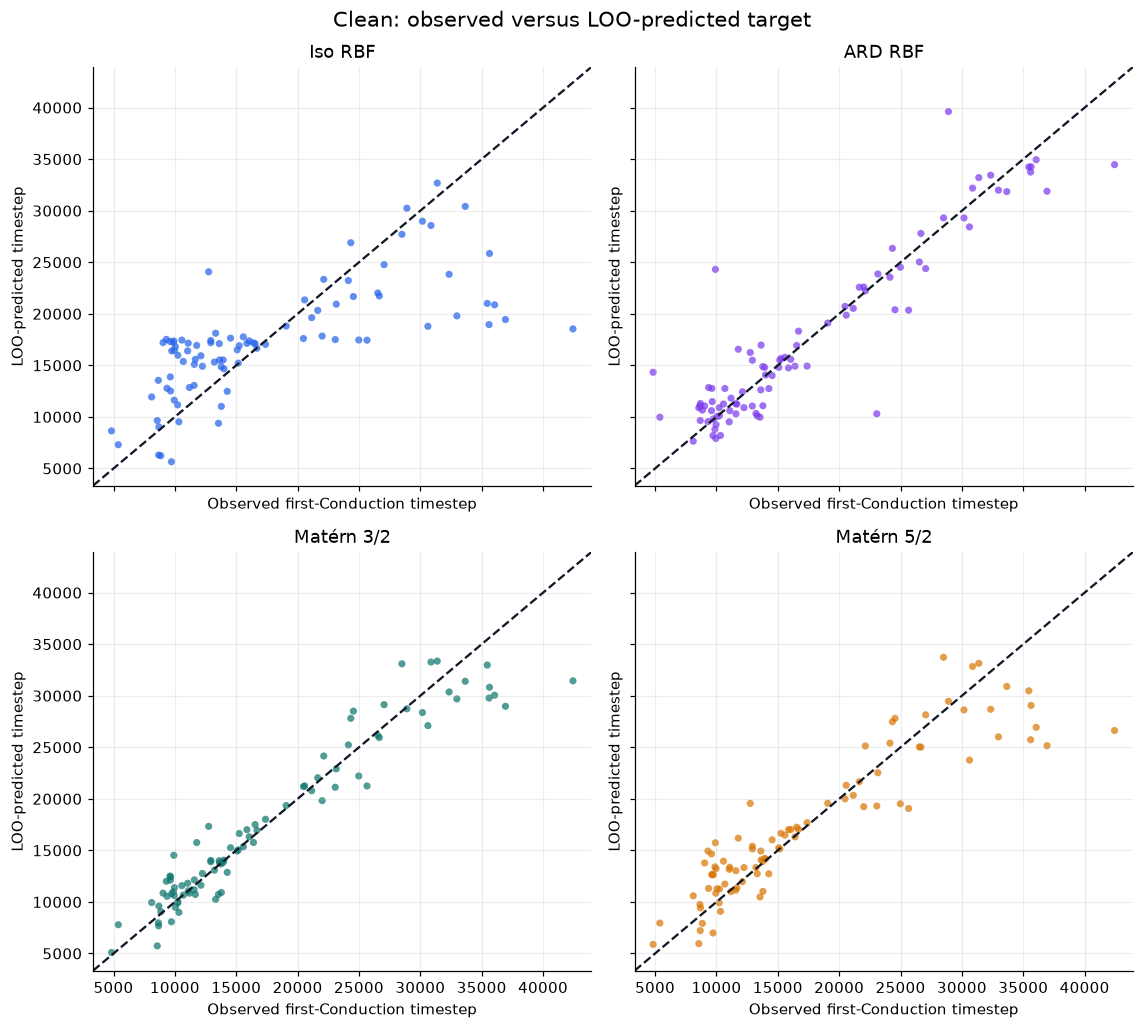

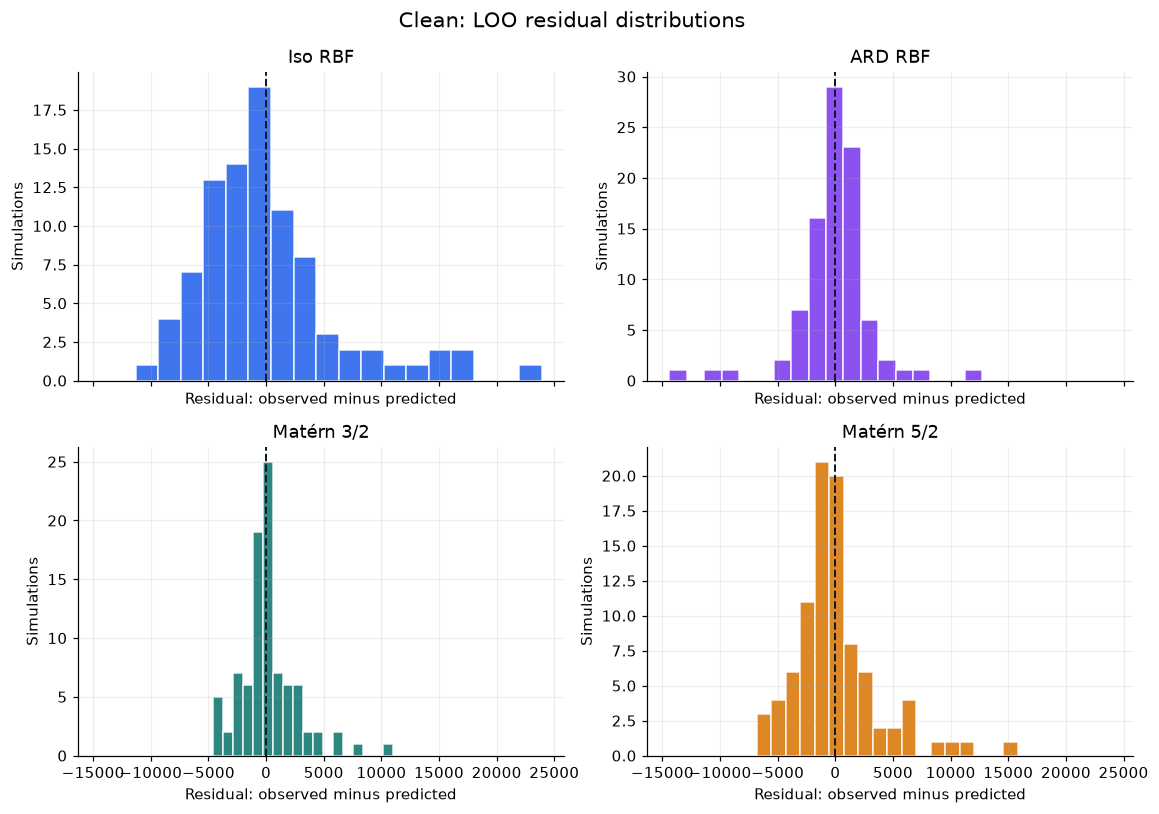

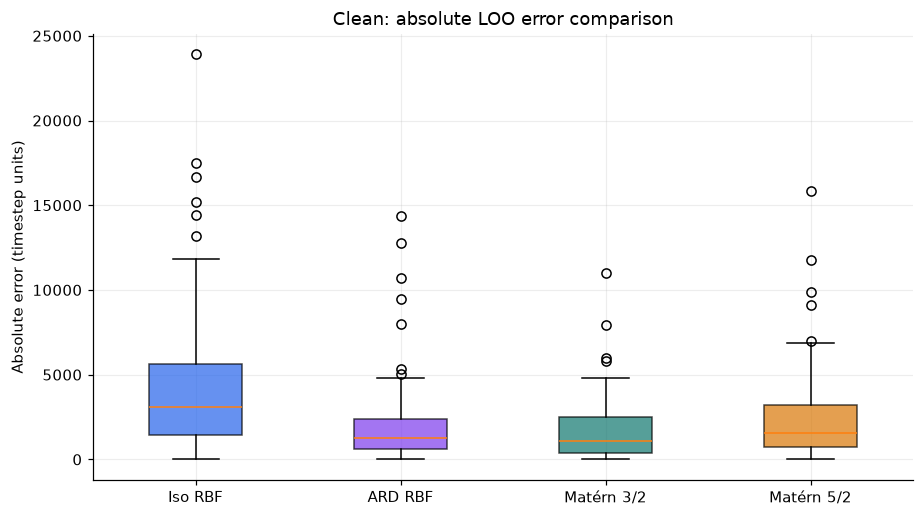

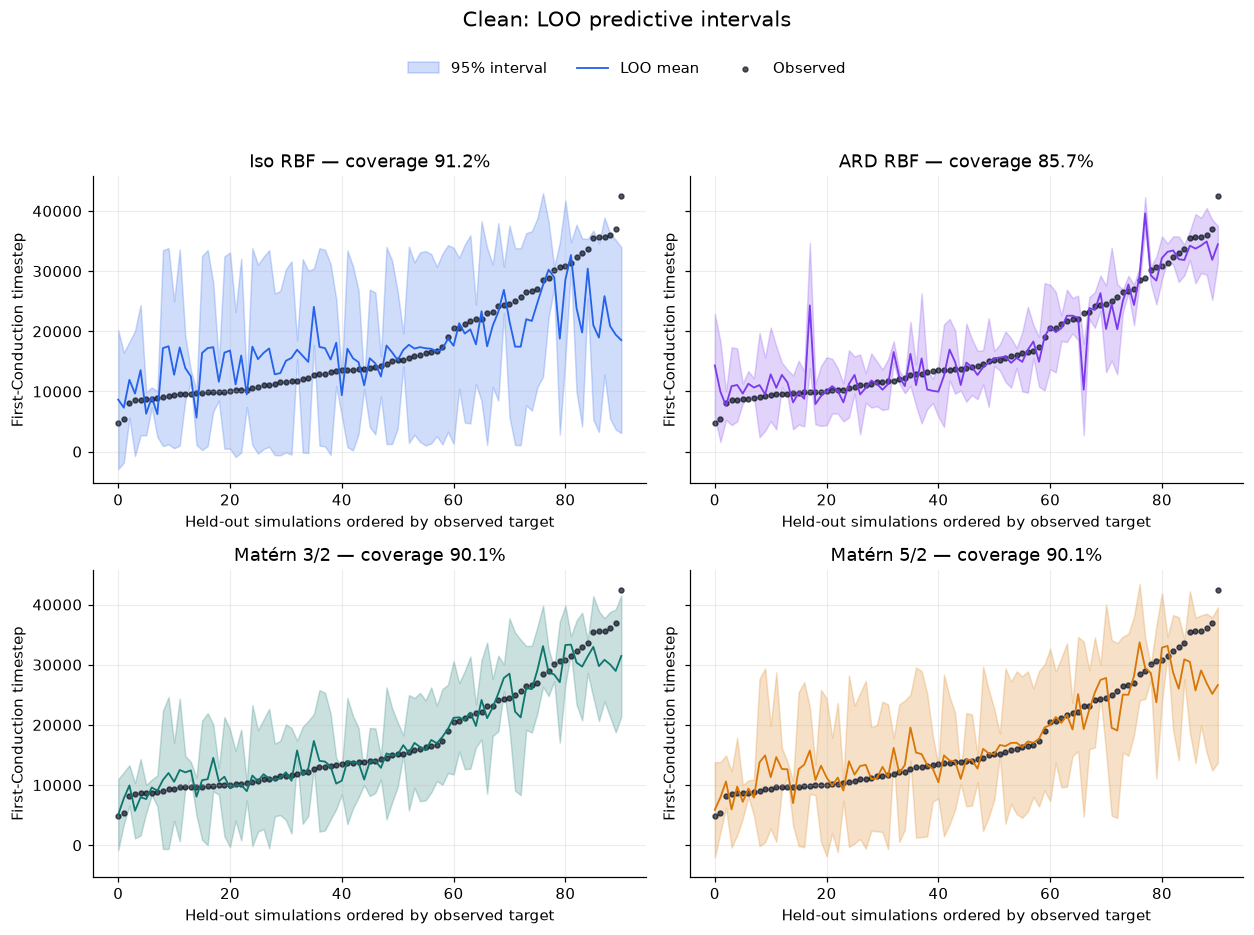

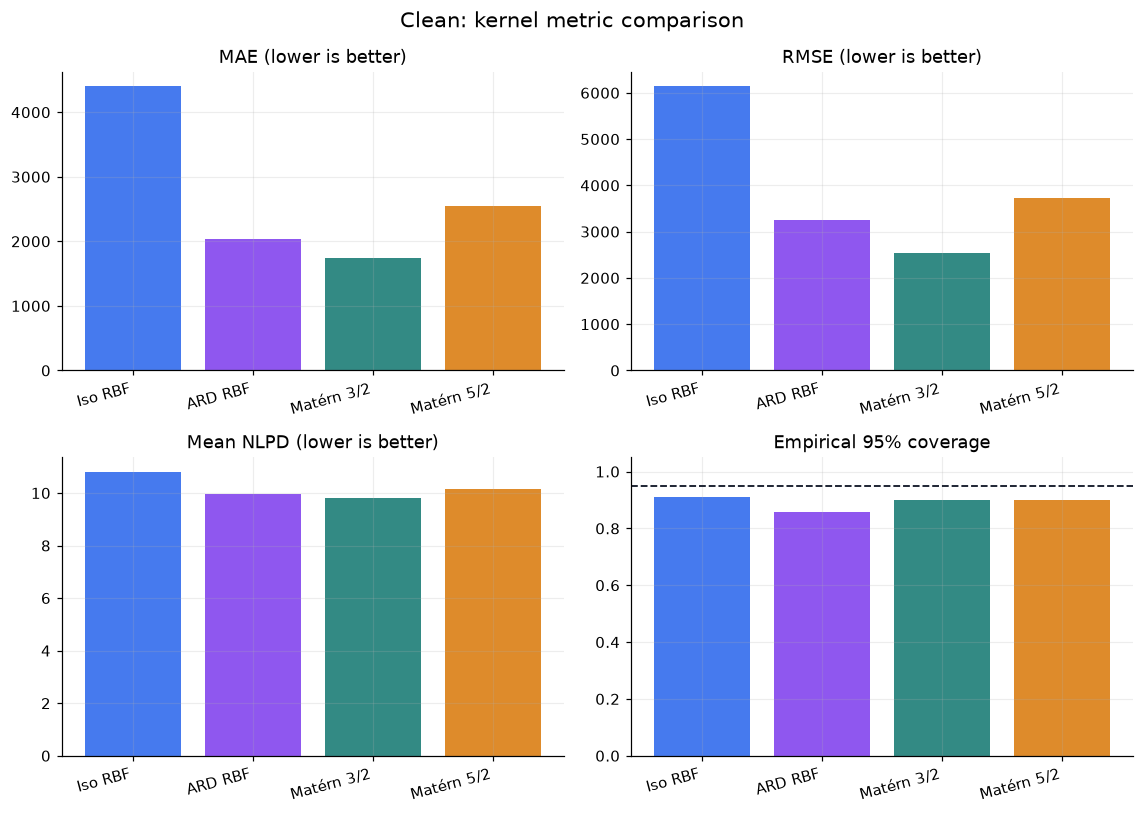

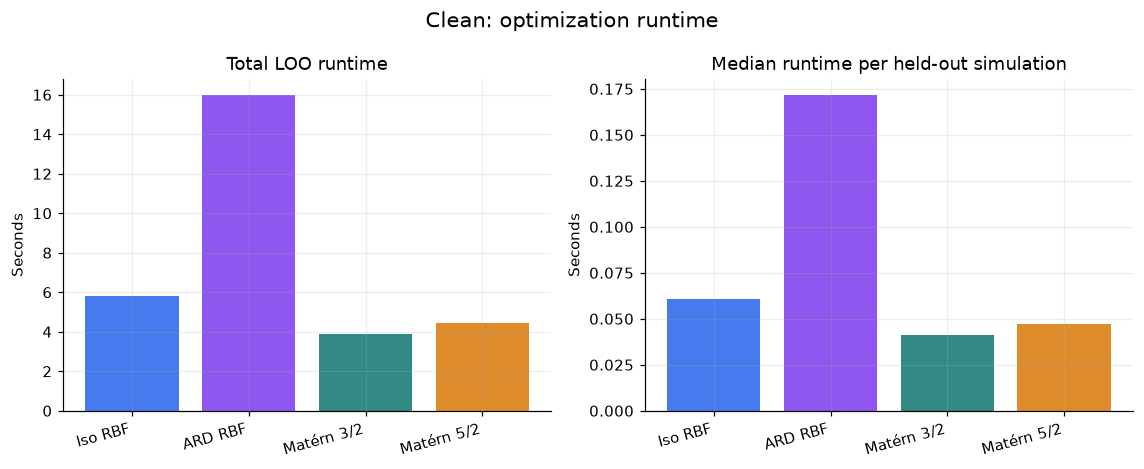

**Clean-figure interpretation.** The observed-versus-predicted panels show agreement and systematic deviations; residual and absolute-error plots reveal spread and outliers; interval panels show whether uncertainty covers the held-out value; metric and runtime panels expose accuracy-calibration-cost trade-offs. None of these plots alone establishes a physically correct transition target.

In [10]:
clean_figure_paths = plot_dataset_diagnostics(
    "clean", clean_loo_predictions, clean_kernel_metrics, CLEAN_DIR
)
display(
    Markdown(
        "**Clean-figure interpretation.** The observed-versus-predicted panels show agreement and systematic deviations; residual and absolute-error plots reveal spread and outliers; interval panels show whether uncertainty covers the held-out value; metric and runtime panels expose accuracy-calibration-cost trade-offs. None of these plots alone establishes a physically correct transition target."
    )
)


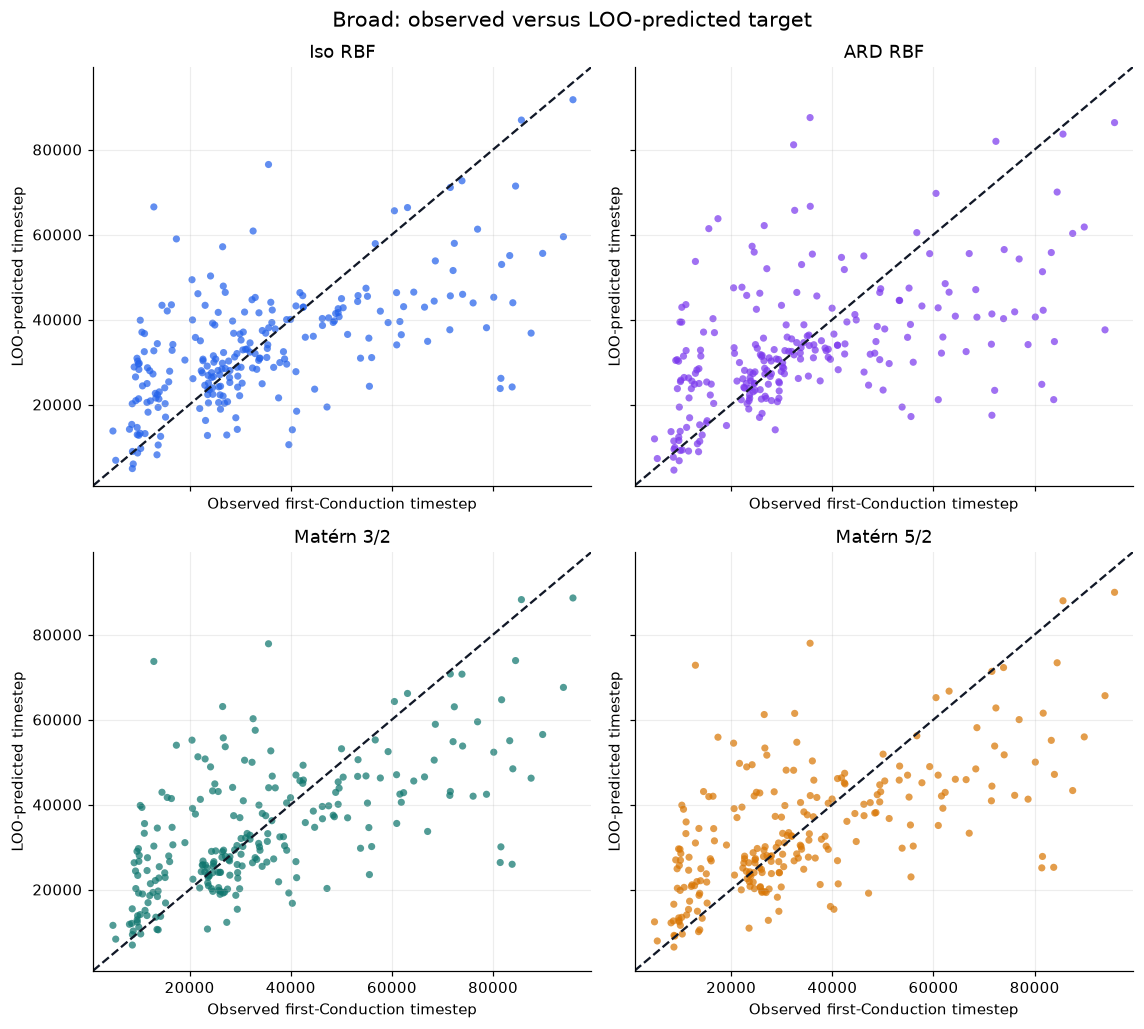

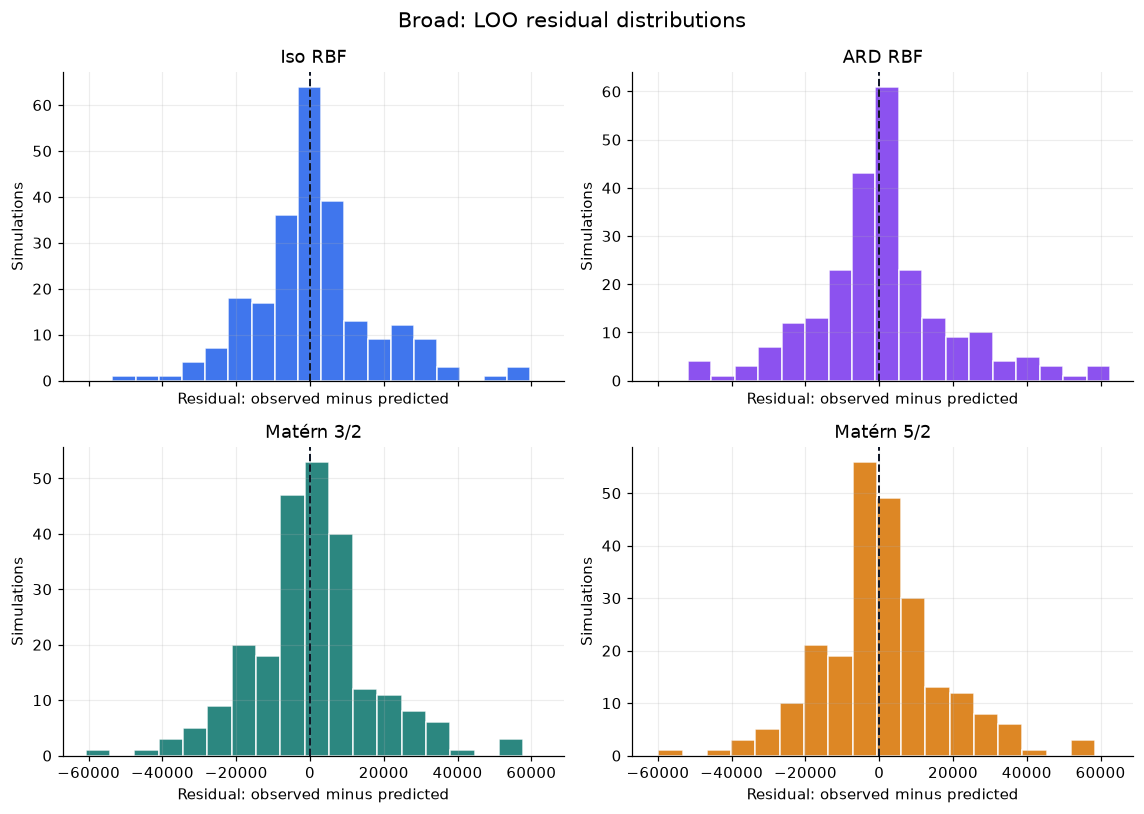

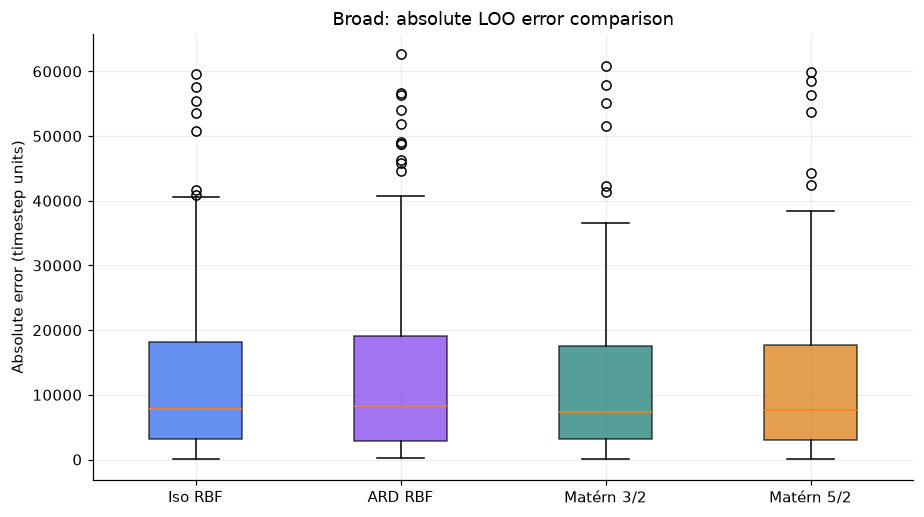

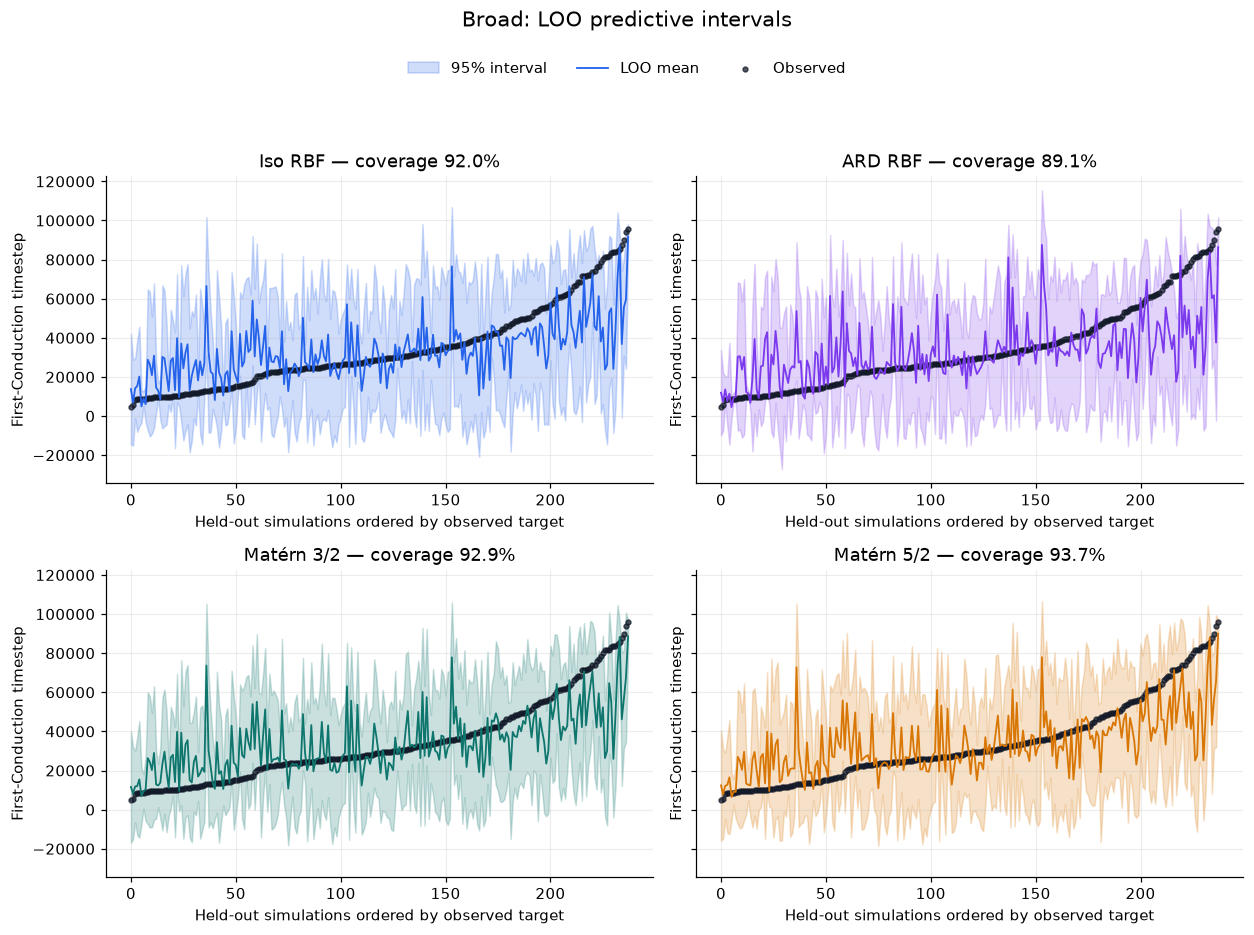

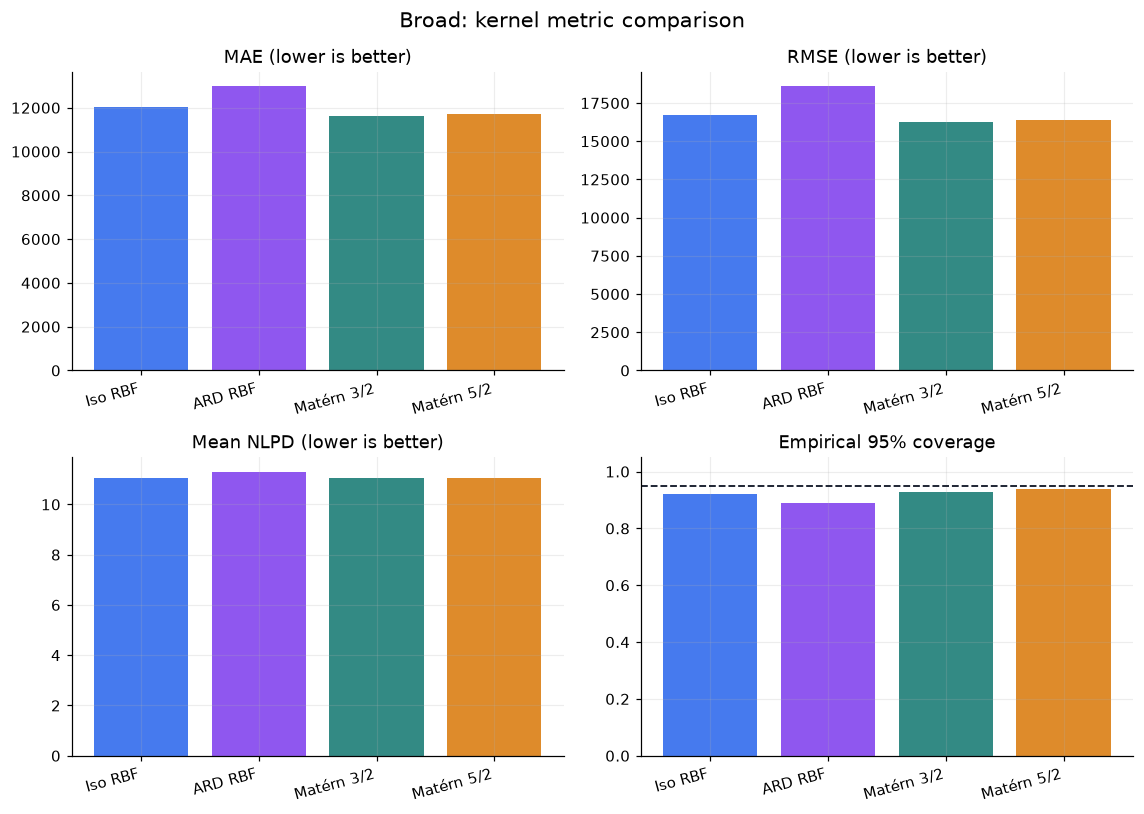

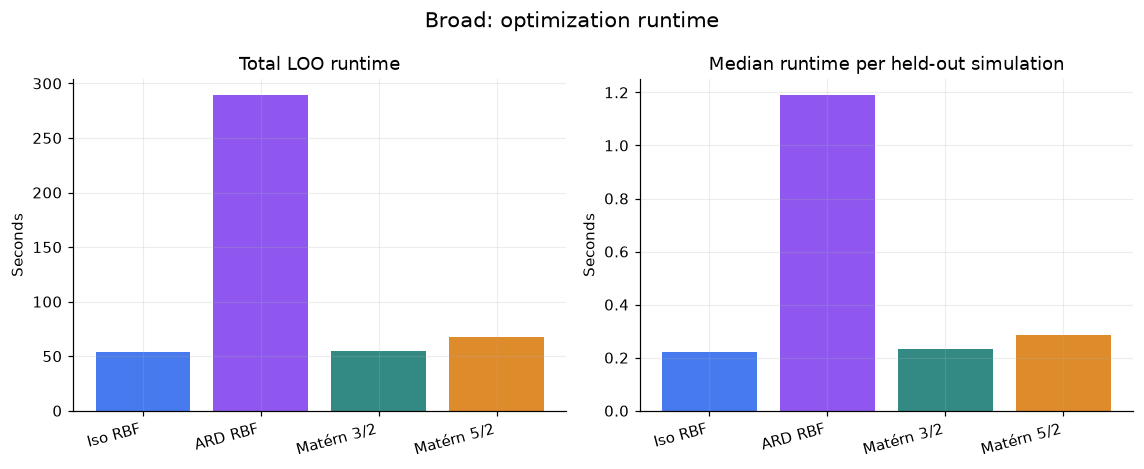

**Broad-figure interpretation.** These panels use the same visual scales and definitions as the clean analysis, but the held-out set is larger and includes bug-affected point targets. Changes in error, coverage, or residual shape can reflect both extra process-space coverage and a different target distribution; they cannot by themselves validate the bug-affected labels.

In [11]:
broad_figure_paths = plot_dataset_diagnostics(
    "broad", broad_loo_predictions, broad_kernel_metrics, BROAD_DIR
)
display(
    Markdown(
        "**Broad-figure interpretation.** These panels use the same visual scales and definitions as the clean analysis, but the held-out set is larger and includes bug-affected point targets. Changes in error, coverage, or residual shape can reflect both extra process-space coverage and a different target distribution; they cannot by themselves validate the bug-affected labels."
    )
)


## 8. Same-clean-points paired comparison


In [12]:
clean_names = set(clean_data[GROUP_COLUMN])
clean_side = clean_loo_predictions[
    [
        GROUP_COLUMN, "kernel_key", "kernel_label", "observed_target",
        "predicted_mean", "predicted_std", "absolute_error", "screenshot_bug_any",
    ]
].rename(
    columns={
        "predicted_mean": "clean_trained_prediction",
        "predicted_std": "clean_trained_std",
        "absolute_error": "clean_trained_absolute_error",
        "screenshot_bug_any": "heldout_screenshot_bug_any",
    }
)
broad_side = broad_loo_predictions.loc[
    broad_loo_predictions[GROUP_COLUMN].isin(clean_names),
    [GROUP_COLUMN, "kernel_key", "observed_target", "predicted_mean", "predicted_std", "absolute_error"],
].rename(
    columns={
        "observed_target": "broad_observed_target_check",
        "predicted_mean": "broad_trained_prediction",
        "predicted_std": "broad_trained_std",
        "absolute_error": "broad_trained_absolute_error",
    }
)
same_clean_points_comparison = clean_side.merge(
    broad_side,
    on=[GROUP_COLUMN, "kernel_key"],
    how="inner",
    validate="one_to_one",
)
if len(same_clean_points_comparison) != EXPECTED_CLEAN_SIZE * len(KERNEL_ORDER):
    raise RuntimeError("Same-clean comparison does not contain 91 paired rows per kernel.")
if not same_clean_points_comparison["observed_target"].eq(
    same_clean_points_comparison["broad_observed_target_check"]
).all():
    raise RuntimeError("Clean and broad evaluations disagree on a held-out clean target.")

same_clean_points_comparison["paired_absolute_error_difference_broad_minus_clean"] = (
    same_clean_points_comparison["broad_trained_absolute_error"]
    - same_clean_points_comparison["clean_trained_absolute_error"]
)
same_clean_points_comparison["paired_improvement_clean_minus_broad"] = (
    same_clean_points_comparison["clean_trained_absolute_error"]
    - same_clean_points_comparison["broad_trained_absolute_error"]
)
same_clean_points_comparison["paired_outcome"] = np.select(
    [
        same_clean_points_comparison["broad_trained_absolute_error"]
        < same_clean_points_comparison["clean_trained_absolute_error"],
        same_clean_points_comparison["broad_trained_absolute_error"]
        > same_clean_points_comparison["clean_trained_absolute_error"],
    ],
    ["improved_by_broad_training", "worsened_by_broad_training"],
    default="tie",
)

same_clean_metric_rows = []
for kernel_key in KERNEL_ORDER:
    subset = same_clean_points_comparison.loc[
        same_clean_points_comparison["kernel_key"].eq(kernel_key)
    ]
    y_true = subset["observed_target"].to_numpy(dtype=float)
    clean_pred = subset["clean_trained_prediction"].to_numpy(dtype=float)
    broad_pred = subset["broad_trained_prediction"].to_numpy(dtype=float)
    same_clean_metric_rows.append(
        {
            "kernel_key": kernel_key,
            "kernel_label": KERNEL_LABELS[kernel_key],
            "clean_evaluation_points": int(len(subset)),
            "clean_trained_MAE": float(mean_absolute_error(y_true, clean_pred)),
            "clean_trained_RMSE": float(math.sqrt(mean_squared_error(y_true, clean_pred))),
            "broad_trained_MAE": float(mean_absolute_error(y_true, broad_pred)),
            "broad_trained_RMSE": float(math.sqrt(mean_squared_error(y_true, broad_pred))),
            "mean_paired_improvement_clean_minus_broad": float(
                subset["paired_improvement_clean_minus_broad"].mean()
            ),
            "median_paired_improvement_clean_minus_broad": float(
                subset["paired_improvement_clean_minus_broad"].median()
            ),
            "clean_points_improved_by_broad_training": int(
                subset["paired_outcome"].eq("improved_by_broad_training").sum()
            ),
            "clean_points_worsened_by_broad_training": int(
                subset["paired_outcome"].eq("worsened_by_broad_training").sum()
            ),
            "clean_points_tied": int(subset["paired_outcome"].eq("tie").sum()),
        }
    )
same_clean_points_metrics = pd.DataFrame(same_clean_metric_rows)
same_clean_points_comparison.to_csv(
    SAME_CLEAN_DIR / "same_clean_points_comparison.csv", index=False
)
same_clean_points_metrics.to_csv(
    SAME_CLEAN_DIR / "same_clean_points_metrics.csv", index=False
)
display(same_clean_points_metrics.round(5))


,kernel_key,kernel_label,clean_evaluation_points,clean_trained_MAE,clean_trained_RMSE,broad_trained_MAE,broad_trained_RMSE,mean_paired_improvement_clean_minus_broad,median_paired_improvement_clean_minus_broad,clean_points_improved_by_broad_training,clean_points_worsened_by_broad_training,clean_points_tied
0,isotropic_rbf,Isotropic RBF,91,4402.15937,6141.66781,12850.80526,16433.61160,-8448.64589,-7422.73032,13,78,0
1,ard_rbf,ARD RBF — Automatic Relevance Determination RBF,91,2035.49111,3255.02170,13454.04746,18429.41275,-11418.55635,-8506.67306,17,74,0
2,matern_3_2,Matérn 3/2,91,1735.76525,2537.00693,13303.69068,17398.49111,-11567.92543,-9689.57949,10,81,0
3,matern_5_2,Matérn 5/2,91,2545.31539,3724.58075,13077.15889,17094.97612,-10531.84350,-8775.00620,12,79,0


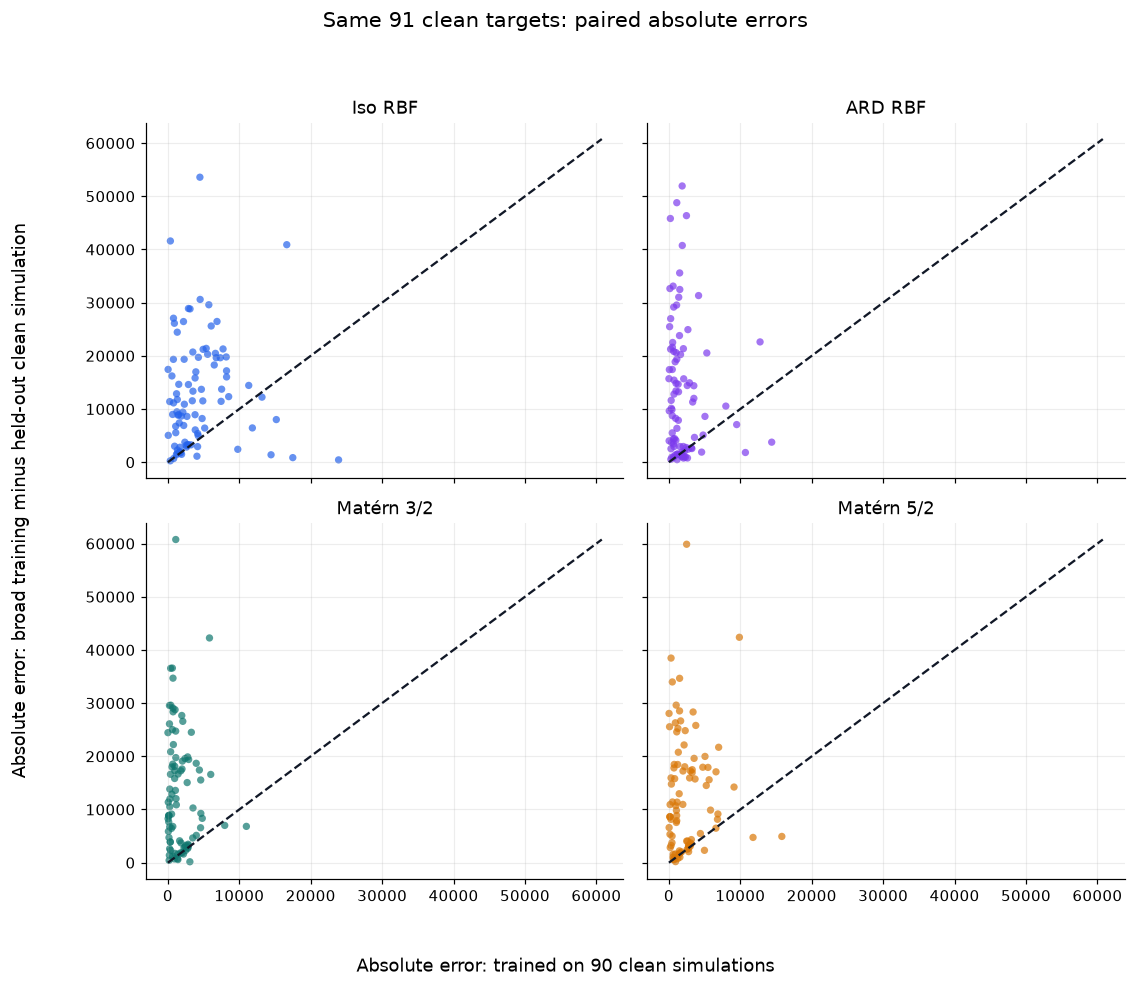

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.0), sharex=True, sharey=True)
paired_limit = float(
    same_clean_points_comparison[
        ["clean_trained_absolute_error", "broad_trained_absolute_error"]
    ].to_numpy().max()
)
for axis, kernel_key in zip(axes.flat, KERNEL_ORDER):
    subset = same_clean_points_comparison.loc[
        same_clean_points_comparison["kernel_key"].eq(kernel_key)
    ]
    axis.scatter(
        subset["clean_trained_absolute_error"],
        subset["broad_trained_absolute_error"],
        color=KERNEL_COLORS[kernel_key], alpha=0.7, s=23, edgecolor="none",
    )
    axis.plot([0, paired_limit], [0, paired_limit], "--", color="#111827")
    axis.set_title(KERNEL_SHORT_LABELS[kernel_key])
fig.supxlabel("Absolute error: trained on 90 clean simulations", y=0.02)
fig.supylabel(
    "Absolute error: broad training minus held-out clean simulation", x=0.02
)
fig.suptitle("Same 91 clean targets: paired absolute errors", fontsize=14, y=0.995)
paired_plot_path = SAME_CLEAN_DIR / "same_clean_points_paired_error_plot.png"
save_and_show(fig, paired_plot_path, tight_rect=(0.04, 0.04, 1, 0.96))


In [14]:
broad_help_count = int(
    (same_clean_points_metrics["broad_trained_RMSE"]
     < same_clean_points_metrics["clean_trained_RMSE"]).sum()
)
paired_best = same_clean_points_metrics.sort_values("broad_trained_RMSE").iloc[0]
display(
    Markdown(
        f'''
        **Plain-language interpretation.** Broad training reduces RMSE on the same 91 clean targets for **{broad_help_count} of 4 kernels**. The lowest broad-trained RMSE on those fixed clean targets is {paired_best['broad_trained_RMSE']:.1f} for **{paired_best['kernel_label']}**. The per-simulation improved/worsened counts and paired error differences show whether aggregate gains are widespread or concentrated. This tests whether the additional broad observations help prediction on clean targets; it does not prove that the bug-affected labels are correct.
        '''
    )
)



        **Plain-language interpretation.** Broad training reduces RMSE on the same 91 clean targets for **0 of 4 kernels**. The lowest broad-trained RMSE on those fixed clean targets is 16433.6 for **Isotropic RBF**. The per-simulation improved/worsened counts and paired error differences show whether aggregate gains are widespread or concentrated. This tests whether the additional broad observations help prediction on clean targets; it does not prove that the bug-affected labels are correct.
        

## 9. Full-data fits and ARD diagnostics


In [15]:
def fit_full_dataset(dataset_name: str, frame: pd.DataFrame) -> pd.DataFrame:
    X = frame[INPUT_COLUMNS].to_numpy(dtype=float)
    y = frame[TARGET_COLUMN].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    rows = []
    for kernel_key in KERNEL_ORDER:
        model = make_gpr(kernel_key)
        fit_start = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            model.fit(X_scaled, y)
        fit_runtime = time.perf_counter() - fit_start
        warning_count, warning_categories, warning_messages = warning_text(caught)
        hyperparameters = extract_kernel_parameters(model.kernel_)
        row = {
            "dataset": dataset_name,
            "kernel_key": kernel_key,
            "kernel_label": KERNEL_LABELS[kernel_key],
            "training_simulations": int(len(frame)),
            "optimized_kernel_expression": str(model.kernel_),
            "log_marginal_likelihood": float(model.log_marginal_likelihood_value_),
            "fit_runtime_seconds": fit_runtime,
            "optimization_warning_count": warning_count,
            "optimization_warning_categories": warning_categories,
            "optimization_warning_messages": warning_messages,
            "optimization_failure": False,
            "alpha_jitter": ALPHA_JITTER,
            "optimizer": OPTIMIZER,
            "extra_optimizer_restarts": N_RESTARTS_OPTIMIZER,
            "normalize_y": NORMALIZE_Y,
            **hyperparameters,
        }
        for input_name, mean_value, scale_value in zip(
            INPUT_COLUMNS, scaler.mean_, scaler.scale_
        ):
            row[f"full_scaler_mean_{input_name}"] = float(mean_value)
            row[f"full_scaler_scale_{input_name}"] = float(scale_value)
        rows.append(row)
    return pd.DataFrame(rows)

full_data_kernel_fits = pd.concat(
    [
        fit_full_dataset("clean", clean_data),
        fit_full_dataset("broad", broad_data),
    ],
    ignore_index=True,
)
full_data_kernel_fits.to_csv(COMBINED_DIR / "full_data_kernel_fits.csv", index=False)
display(
    full_data_kernel_fits[
        [
            "dataset", "kernel_label", "optimized_kernel_expression",
            "log_marginal_likelihood", "signal_variance", "isotropic_lengthscale",
            "ard_lengthscale_P", "ard_lengthscale_VX", "ard_lengthscale_LS",
            "ard_lengthscale_ST", "optimization_warning_count", "fit_runtime_seconds",
        ]
    ].round(5)
)


,dataset,kernel_label,optimized_kernel_expression,log_marginal_likelihood,signal_variance,isotropic_lengthscale,ard_lengthscale_P,ard_lengthscale_VX,ard_lengthscale_LS,ard_lengthscale_ST,optimization_warning_count,fit_runtime_seconds
0,clean,Isotropic RBF,0.945**2 * RBF(length_scale=0.419),-102.84135,0.89374,0.41903,NaN,NaN,NaN,NaN,0,0.04940
1,clean,ARD RBF — Automatic Relevance Determination RBF,"0.815**2 * RBF(length_scale=[0.764, 0.266, 100, 1.73])",-44.55502,0.66379,NaN,0.76418,0.26561,100.00000,1.73317,1,0.09987
2,clean,Matérn 3/2,"0.88**2 * Matern(length_scale=1.16, nu=1.5)",-61.61715,0.77406,1.15751,NaN,NaN,NaN,NaN,0,0.04056
3,clean,Matérn 5/2,"0.861**2 * Matern(length_scale=0.709, nu=2.5)",-80.22925,0.74213,0.70920,NaN,NaN,NaN,NaN,0,0.03825
4,broad,Isotropic RBF,1**2 * RBF(length_scale=0.453),-288.86234,1.00930,0.45297,NaN,NaN,NaN,NaN,0,0.19843
5,broad,ARD RBF — Automatic Relevance Determination RBF,"0.997**2 * RBF(length_scale=[0.945, 0.404, 0.82, 0.158])",-276.90591,0.99309,NaN,0.94493,0.40447,0.82005,0.15789,0,0.97410
6,broad,Matérn 3/2,"1.01**2 * Matern(length_scale=0.623, nu=1.5)",-282.06280,1.02043,0.62323,NaN,NaN,NaN,NaN,0,0.18894
7,broad,Matérn 5/2,"1.01**2 * Matern(length_scale=0.554, nu=2.5)",-283.72078,1.01296,0.55447,NaN,NaN,NaN,NaN,0,0.28084


**Interpretation.** These eight fits use every available row in their respective dataset and are saved for scientific interpretation only. They did not generate the LOO predictions above, so their optimized hyperparameters cannot leak into held-out folds. A higher full-data log marginal likelihood is meaningful only within the same dataset and modelling assumptions; it is not a substitute for out-of-sample evaluation.


In [16]:
ard_full_rows = full_data_kernel_fits.loc[
    full_data_kernel_fits["kernel_key"].eq("ard_rbf")
].copy()
ard_lengthscale_rows = []
for full_row in ard_full_rows.itertuples(index=False):
    lengthscales = {
        input_name: float(getattr(full_row, f"ard_lengthscale_{input_name}"))
        for input_name in INPUT_COLUMNS
    }
    anisotropy_ratio = max(lengthscales.values()) / min(lengthscales.values())
    for input_name in INPUT_COLUMNS:
        lengthscale = lengthscales[input_name]
        ard_lengthscale_rows.append(
            {
                "dataset": full_row.dataset,
                "input": input_name,
                "standardized_space_lengthscale": lengthscale,
                "inverse_lengthscale_diagnostic": 1.0 / lengthscale,
                "full_fit_anisotropy_ratio_max_over_min": anisotropy_ratio,
                "interpretation": "descriptive model diagnostic; not causal feature importance",
            }
        )
ard_lengthscale_summary = pd.DataFrame(ard_lengthscale_rows)
ard_lengthscale_summary.to_csv(COMBINED_DIR / "ard_lengthscale_summary.csv", index=False)

ard_fold_frames = []
for dataset_name, predictions in [
    ("clean", clean_loo_predictions), ("broad", broad_loo_predictions)
]:
    ard_subset = predictions.loc[predictions["kernel_key"].eq("ard_rbf")].copy()
    folded = ard_subset[
        ["dataset", "fold_index", GROUP_COLUMN]
        + [f"ard_lengthscale_{input_name}" for input_name in INPUT_COLUMNS]
    ].melt(
        id_vars=["dataset", "fold_index", GROUP_COLUMN],
        value_vars=[f"ard_lengthscale_{input_name}" for input_name in INPUT_COLUMNS],
        var_name="input",
        value_name="standardized_space_lengthscale",
    )
    folded["input"] = folded["input"].str.replace("ard_lengthscale_", "", regex=False)
    ard_fold_frames.append(folded)
ard_fold_lengthscales = pd.concat(ard_fold_frames, ignore_index=True)
ard_fold_lengthscales.to_csv(COMBINED_DIR / "ard_fold_lengthscales.csv", index=False)
display(ard_lengthscale_summary.round(5))


,dataset,input,standardized_space_lengthscale,inverse_lengthscale_diagnostic,full_fit_anisotropy_ratio_max_over_min,interpretation
0,clean,P,0.76418,1.30860,376.49513,descriptive model diagnostic; not causal feature importance
1,clean,VX,0.26561,3.76495,376.49513,descriptive model diagnostic; not causal feature importance
2,clean,LS,100.00000,0.01000,376.49513,descriptive model diagnostic; not causal feature importance
3,clean,ST,1.73317,0.57698,376.49513,descriptive model diagnostic; not causal feature importance
4,broad,P,0.94493,1.05828,5.98492,descriptive model diagnostic; not causal feature importance
5,broad,VX,0.40447,2.47239,5.98492,descriptive model diagnostic; not causal feature importance
6,broad,LS,0.82005,1.21943,5.98492,descriptive model diagnostic; not causal feature importance
7,broad,ST,0.15789,6.33370,5.98492,descriptive model diagnostic; not causal feature importance


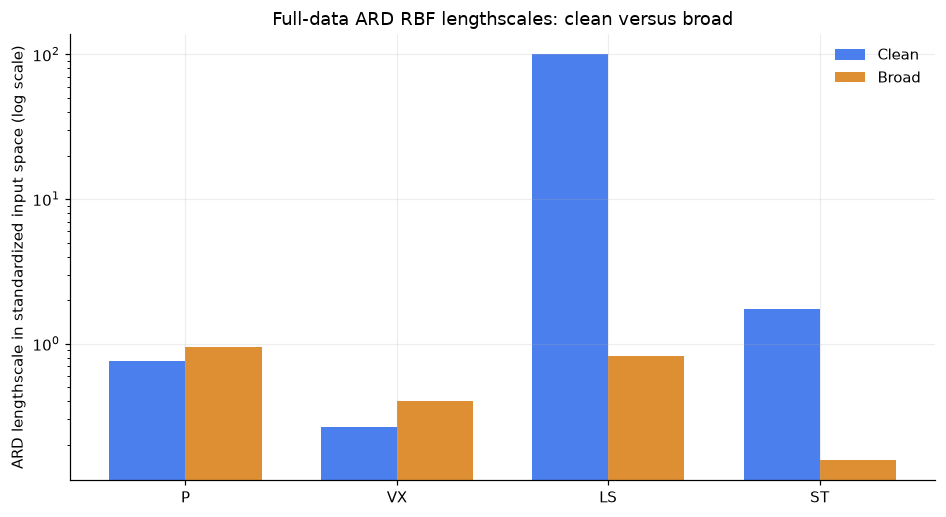

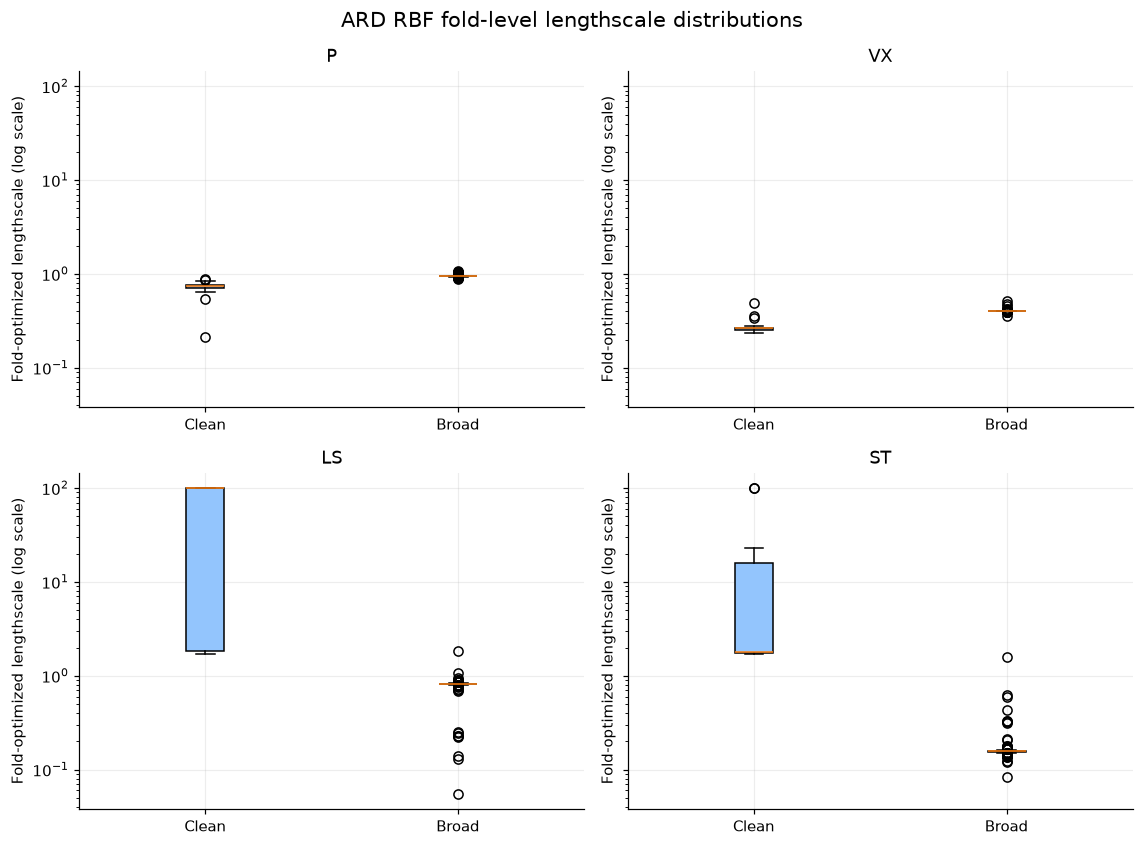

In [17]:
fig, axis = plt.subplots(figsize=(8.7, 4.8))
x = np.arange(len(INPUT_COLUMNS))
width = 0.36
for offset, dataset_name, color in [
    (-width / 2, "clean", "#2563EB"),
    (width / 2, "broad", "#D97706"),
]:
    values = (
        ard_lengthscale_summary.loc[
            ard_lengthscale_summary["dataset"].eq(dataset_name)
        ].set_index("input").loc[INPUT_COLUMNS, "standardized_space_lengthscale"]
    )
    axis.bar(x + offset, values, width=width, label=dataset_name.title(), color=color, alpha=0.82)
axis.set_xticks(x, INPUT_COLUMNS)
axis.set_yscale("log")
axis.set_ylabel("ARD lengthscale in standardized input space (log scale)")
axis.set_title("Full-data ARD RBF lengthscales: clean versus broad")
axis.legend(frameon=False)
ard_full_plot_path = COMBINED_DIR / "ard_lengthscale_clean_vs_broad.png"
save_and_show(fig, ard_full_plot_path)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.8), sharey=True)
for axis, input_name in zip(axes.flat, INPUT_COLUMNS):
    clean_values = ard_fold_lengthscales.loc[
        ard_fold_lengthscales["dataset"].eq("clean")
        & ard_fold_lengthscales["input"].eq(input_name),
        "standardized_space_lengthscale",
    ].to_numpy()
    broad_values = ard_fold_lengthscales.loc[
        ard_fold_lengthscales["dataset"].eq("broad")
        & ard_fold_lengthscales["input"].eq(input_name),
        "standardized_space_lengthscale",
    ].to_numpy()
    box = axis.boxplot(
        [clean_values, broad_values], tick_labels=["Clean", "Broad"],
        patch_artist=True, showfliers=True,
    )
    box["boxes"][0].set_facecolor("#93C5FD")
    box["boxes"][1].set_facecolor("#FCD34D")
    axis.set_yscale("log")
    axis.set_title(input_name)
    axis.set_ylabel("Fold-optimized lengthscale (log scale)")
fig.suptitle("ARD RBF fold-level lengthscale distributions", fontsize=14)
ard_fold_plot_path = COMBINED_DIR / "ard_fold_lengthscale_distributions.png"
save_and_show(fig, ard_fold_plot_path)


In [18]:
ard_interpretation_lines = []
for dataset_name in ["clean", "broad"]:
    subset = ard_lengthscale_summary.loc[
        ard_lengthscale_summary["dataset"].eq(dataset_name)
    ].sort_values("standardized_space_lengthscale")
    shortest = subset.iloc[0]
    longest = subset.iloc[-1]
    ratio = float(subset["full_fit_anisotropy_ratio_max_over_min"].iloc[0])
    ard_interpretation_lines.append(
        f"- **{dataset_name.title()}:** shortest lengthscale {shortest['input']}="
        f"{shortest['standardized_space_lengthscale']:.3g}; longest {longest['input']}="
        f"{longest['standardized_space_lengthscale']:.3g}; max/min ratio {ratio:.2f}."
    )
display(
    Markdown(
        "**Plain-language ARD interpretation.** Shorter standardized-space lengthscales mean the fitted function varies more rapidly along that coordinate, conditional on this model and dataset.\n\n"
        + "\n".join(ard_interpretation_lines)
        + "\n\nThese patterns are descriptive diagnostics, not causal importance scores; fold-level dispersion shows how stable or unstable the estimates are when one simulation is removed."
    )
)


**Plain-language ARD interpretation.** Shorter standardized-space lengthscales mean the fitted function varies more rapidly along that coordinate, conditional on this model and dataset.

- **Clean:** shortest lengthscale VX=0.266; longest LS=100; max/min ratio 376.50.
- **Broad:** shortest lengthscale ST=0.158; longest P=0.945; max/min ratio 5.98.

These patterns are descriptive diagnostics, not causal importance scores; fold-level dispersion shows how stable or unstable the estimates are when one simulation is removed.

## 10. Rankings, optimizer diagnostics, and structured summaries


In [19]:
def add_metric_ranks(metrics: pd.DataFrame) -> pd.DataFrame:
    ranked = metrics.copy()
    rank_directions = {
        "MAE": True,
        "median_absolute_error": True,
        "RMSE": True,
        "R2": False,
        "normalized_RMSE": True,
        "mean_negative_log_predictive_density": True,
        "coverage_error_from_0_95": True,
        "total_runtime_seconds": True,
    }
    for metric_name, ascending in rank_directions.items():
        ranked[f"rank_{metric_name}"] = (
            ranked[metric_name].rank(method="min", ascending=ascending).astype(int)
        )
    ranked["primary_RMSE_rank"] = ranked["rank_RMSE"]
    return ranked

clean_rankings = add_metric_ranks(clean_kernel_metrics)
broad_rankings = add_metric_ranks(broad_kernel_metrics)
kernel_metric_rankings = pd.concat([clean_rankings, broad_rankings], ignore_index=True)
kernel_metric_rankings.to_csv(COMBINED_DIR / "kernel_metric_rankings.csv", index=False)

loo_optimizer_diagnostics = pd.concat(
    [clean_loo_predictions, broad_loo_predictions], ignore_index=True
)[
    [
        "dataset", "fold_index", GROUP_COLUMN, "kernel_key", "kernel_label",
        "training_simulations", "fit_runtime_seconds", "predict_runtime_seconds",
        "fold_runtime_seconds", "optimization_warning_count",
        "optimization_warning_categories", "optimization_warning_messages",
        "fit_failed", "optimized_kernel_expression",
    ]
].copy()
loo_optimizer_diagnostics.insert(0, "evaluation_type", "loo_fold")

full_optimizer_diagnostics = full_data_kernel_fits[
    [
        "dataset", "kernel_key", "kernel_label", "training_simulations",
        "fit_runtime_seconds", "optimization_warning_count",
        "optimization_warning_categories", "optimization_warning_messages",
        "optimization_failure", "optimized_kernel_expression",
    ]
].copy()
full_optimizer_diagnostics.insert(0, "evaluation_type", "full_data_fit")
full_optimizer_diagnostics["fold_index"] = pd.NA
full_optimizer_diagnostics[GROUP_COLUMN] = pd.NA
full_optimizer_diagnostics["predict_runtime_seconds"] = 0.0
full_optimizer_diagnostics["fold_runtime_seconds"] = full_optimizer_diagnostics[
    "fit_runtime_seconds"
]
full_optimizer_diagnostics = full_optimizer_diagnostics.rename(
    columns={"optimization_failure": "fit_failed"}
)
optimizer_diagnostics = pd.concat(
    [loo_optimizer_diagnostics, full_optimizer_diagnostics],
    ignore_index=True,
    sort=False,
)
optimizer_diagnostics.to_csv(COMBINED_DIR / "optimizer_diagnostics.csv", index=False)
display(
    kernel_metric_rankings[
        [
            "dataset", "kernel_label", "primary_RMSE_rank", "rank_MAE",
            "rank_mean_negative_log_predictive_density", "rank_coverage_error_from_0_95",
            "optimization_warning_count", "total_runtime_seconds",
        ]
    ].sort_values(["dataset", "primary_RMSE_rank"])
)


,dataset,kernel_label,primary_RMSE_rank,rank_MAE,rank_mean_negative_log_predictive_density,rank_coverage_error_from_0_95,optimization_warning_count,total_runtime_seconds
6,broad,Matérn 3/2,1,1,3,2,0,55.02532
7,broad,Matérn 5/2,2,2,1,1,0,67.81810
4,broad,Isotropic RBF,3,3,2,3,0,53.62302
5,broad,ARD RBF — Automatic Relevance Determination RBF,4,4,4,4,0,289.52903
2,clean,Matérn 3/2,1,1,1,2,0,3.88540
1,clean,ARD RBF — Automatic Relevance Determination RBF,2,2,2,4,49,15.99556
3,clean,Matérn 5/2,3,3,3,2,0,4.44655
0,clean,Isotropic RBF,4,4,4,1,0,5.78993


In [20]:
def compact_markdown_table(frame: pd.DataFrame, columns: list[str]) -> str:
    def format_value(value) -> str:
        if pd.isna(value):
            return "—"
        if isinstance(value, (float, np.floating)):
            if abs(float(value)) >= 1000:
                return f"{float(value):,.1f}"
            return f"{float(value):.4f}"
        return str(value).replace("|", "/")

    header = "| " + " | ".join(columns) + " |"
    separator = "|" + "|".join(["---"] * len(columns)) + "|"
    rows = [
        "| " + " | ".join(format_value(row[column]) for column in columns) + " |"
        for _, row in frame[columns].iterrows()
    ]
    return "\n".join([header, separator, *rows])

def best_metric_lines(metrics: pd.DataFrame) -> list[str]:
    definitions = [
        ("MAE", "lowest MAE", True, "timestep units"),
        ("median_absolute_error", "lowest median absolute error", True, "timestep units"),
        ("RMSE", "lowest RMSE", True, "timestep units"),
        ("R2", "highest R²", False, ""),
        ("normalized_RMSE", "lowest normalized RMSE", True, ""),
        ("mean_negative_log_predictive_density", "lowest mean NLPD", True, ""),
        ("coverage_error_from_0_95", "coverage closest to 95%", True, "absolute coverage error"),
        ("mean_95_interval_width", "narrowest mean 95% interval", True, "timestep units; narrowest is not automatically best"),
        ("total_runtime_seconds", "lowest total runtime", True, "seconds"),
        ("optimization_warning_count", "fewest recorded optimization warnings", True, "warnings"),
    ]
    lines = []
    for column, description, ascending, note in definitions:
        winner = metrics.sort_values(column, ascending=ascending).iloc[0]
        lines.append(
            f"- {description}: **{winner['kernel_label']}** "
            f"({winner[column]:.5g}{'; ' + note if note else ''})."
        )
    return lines

clean_rmse_order = clean_kernel_metrics.sort_values("RMSE")["kernel_key"].tolist()
broad_rmse_order = broad_kernel_metrics.sort_values("RMSE")["kernel_key"].tolist()
clean_rmse_rank_series = clean_kernel_metrics.set_index("kernel_key")["RMSE"].rank()
broad_rmse_rank_series = broad_kernel_metrics.set_index("kernel_key")["RMSE"].rank()
rmse_rank_spearman = float(clean_rmse_rank_series.corr(broad_rmse_rank_series, method="pearson"))
rmse_order_identical = clean_rmse_order == broad_rmse_order
rmse_winner_same = clean_rmse_order[0] == broad_rmse_order[0]

def ard_vs_isotropic_rmse_change(metrics: pd.DataFrame) -> float:
    indexed = metrics.set_index("kernel_key")
    return float(
        100
        * (indexed.loc["isotropic_rbf", "RMSE"] - indexed.loc["ard_rbf", "RMSE"])
        / indexed.loc["isotropic_rbf", "RMSE"]
    )

clean_ard_rmse_change_percent = ard_vs_isotropic_rmse_change(clean_kernel_metrics)
broad_ard_rmse_change_percent = ard_vs_isotropic_rmse_change(broad_kernel_metrics)

same_clean_summary_lines = []
for row in same_clean_points_metrics.itertuples(index=False):
    same_clean_summary_lines.append(
        f"- **{row.kernel_label}:** clean-trained MAE/RMSE "
        f"{row.clean_trained_MAE:.1f}/{row.clean_trained_RMSE:.1f}; broad-trained "
        f"{row.broad_trained_MAE:.1f}/{row.broad_trained_RMSE:.1f}; "
        f"improved/worsened/tied points {row.clean_points_improved_by_broad_training}/"
        f"{row.clean_points_worsened_by_broad_training}/{row.clean_points_tied}; "
        f"median paired improvement {row.median_paired_improvement_clean_minus_broad:.1f}."
    )

calibration_lines = []
for dataset_name, metrics in [("Clean", clean_kernel_metrics), ("Broad", broad_kernel_metrics)]:
    for row in metrics.sort_values("kernel_key").itertuples(index=False):
        calibration_lines.append(
            f"- {dataset_name}, {row.kernel_label}: coverage "
            f"{row.empirical_95_interval_coverage:.1%}, mean width {row.mean_95_interval_width:.1f}."
        )

total_loo_runtime_seconds = float(
    clean_kernel_metrics["total_runtime_seconds"].sum()
    + broad_kernel_metrics["total_runtime_seconds"].sum()
)
total_full_fit_runtime_seconds = float(full_data_kernel_fits["fit_runtime_seconds"].sum())
total_warning_count = int(optimizer_diagnostics["optimization_warning_count"].sum())
total_failure_count = int(optimizer_diagnostics["fit_failed"].fillna(False).sum())

clean_metric_log_columns = [
    "kernel_label", "MAE", "median_absolute_error", "RMSE", "R2",
    "normalized_RMSE", "mean_negative_log_predictive_density",
    "empirical_95_interval_coverage", "mean_95_interval_width",
    "total_runtime_seconds", "optimization_warning_count",
]
clean_metric_table_md = compact_markdown_table(
    clean_kernel_metrics.sort_values("RMSE"), clean_metric_log_columns
)
broad_metric_table_md = compact_markdown_table(
    broad_kernel_metrics.sort_values("RMSE"), clean_metric_log_columns
)
same_clean_table_md = compact_markdown_table(
    same_clean_points_metrics,
    [
        "kernel_label", "clean_trained_MAE", "clean_trained_RMSE",
        "broad_trained_MAE", "broad_trained_RMSE",
        "clean_points_improved_by_broad_training",
        "clean_points_worsened_by_broad_training",
        "median_paired_improvement_clean_minus_broad",
    ],
)
ard_table_md = compact_markdown_table(
    ard_lengthscale_summary,
    ["dataset", "input", "standardized_space_lengthscale", "full_fit_anisotropy_ratio_max_over_min"],
)


In [21]:
clean_best_key = clean_rmse_order[0]
broad_best_key = broad_rmse_order[0]
clean_best_label = KERNEL_LABELS[clean_best_key]
broad_best_label = KERNEL_LABELS[broad_best_key]
broad_help_kernel_count = int(
    (same_clean_points_metrics["broad_trained_RMSE"]
     < same_clean_points_metrics["clean_trained_RMSE"]).sum()
)
if rmse_order_identical:
    ranking_statement = "The complete RMSE ordering is identical across clean and broad datasets."
elif rmse_winner_same:
    ranking_statement = "The RMSE winner is shared, but the remaining kernel ordering changes."
else:
    ranking_statement = "The clean and broad datasets select different RMSE winners."

ard_statement = (
    f"ARD RBF changes RMSE relative to isotropic RBF by {clean_ard_rmse_change_percent:+.2f}% "
    f"on clean data and {broad_ard_rmse_change_percent:+.2f}% on broad data "
    "(positive means ARD reduces RMSE)."
)
broad_training_statement = (
    f"Broad training reduces RMSE on the same 91 clean points for {broad_help_kernel_count} of 4 kernels."
)
next_decision = (
    f"Review the highest-error LOO simulations for clean-best {clean_best_label} and broad-best "
    f"{broad_best_label}, cross-reference Screenshot Bug and ambiguity diagnostics, and agree with Ioan "
    "on the primary data policy before any active-learning or level-set work."
)

results_summary_markdown = f'''# Week 5 Experiment 02 — GP Kernel Comparison Results

## Data and protocol

- Clean dataset: {len(clean_data)} simulations.
- Broad dataset: {len(broad_data)} simulations.
- Excluded never-Conduction simulations: {len(never_conduction)}.
- Inputs: P, VX, LS, ST; standardized inside every LOO fold.
- Target: first observed Conduction raw timestep.
- GPR: normalize_y=True, alpha={ALPHA_JITTER:g} numerical jitter, {OPTIMIZER}, {N_RESTARTS_OPTIMIZER} extra restart, no WhiteKernel.

## Clean metrics (ordered by RMSE)

{clean_metric_table_md}

## Broad metrics (ordered by RMSE)

{broad_metric_table_md}

## Same-clean-points comparison

{same_clean_table_md}

## ARD full-data diagnostics

{ard_table_md}

## Interpretation

- {ranking_statement}
- {ard_statement}
- {broad_training_statement}
- Total recorded optimization warnings: {total_warning_count}; failures: {total_failure_count}.
- Summed LOO fold runtime: {total_loo_runtime_seconds:.1f} s; full-data fit runtime: {total_full_fit_runtime_seconds:.1f} s.

## Next decision

{next_decision}

These results concern GP regression on a provisional point target. They do not prove physical transition-time accuracy, causal input importance, or the correctness of bug-affected labels.
'''
results_summary_path = COMBINED_DIR / "week5_02_results_summary.md"
results_summary_path.write_text(results_summary_markdown, encoding="utf-8")


3907

In [22]:
thesis_log = f'''# Week 5 — First-Conduction Gaussian Process Regression Log

This is a cumulative thesis decision record. Later Week 5 phases should preserve the provenance and decisions below and append or carefully extend the relevant results and next-decision sections.

## 1. Supervisor task and scientific objective

The Week 5 task is a real-data Gaussian Process regression warm-up using four process inputs to predict the first observed Conduction timestep. It establishes a reproducible simulation-level regression baseline before any active-learning or level-set-estimation work. This phase is not active learning and does not estimate a level set.

## 2. Data source and provenance

- Hugging Face repository: `{HF_REPOSITORY_ID}`
- CSV filename: `{HF_FILENAME}`
- Pinned revision: `{HF_REVISION}`
- CSV SHA-256: `{CSV_SHA256_EXPECTED}`
- Raw dimensions: 65,472 rows × 12 columns
- One simulation: one unique `name` group
- Total simulations: 241
- Usable first-observed Conduction targets: 238
- Excluded: 3 simulations because no Conduction frame is observed

## 3. Input and target definitions

```text
X = [P, VX, LS, ST]

y = minimum raw timestep for which label_final == "Conduction"
```

- `P` is laser power.
- `VX` is scan velocity.
- `LS` is laser spot radius.
- `ST` is substrate temperature.
- The target is a raw simulation timestep number and is not presented as physical time.
- Frame index is not used as the response.

## 4. Data-audit findings retained for the thesis

- `name` is the valid simulation grouping key; `hash` merges distinct simulations.
- 238 simulations reach Conduction; 91 form the strict-clean subset.
- 147 broad-dataset simulations contain Screenshot Bug before first observed Conduction.
- Three simulations do not reach Conduction.
- `bug_free` is inconsistent with the explicit Screenshot Bug labels.
- `label_1`, `label_2`, and `label_final` are identical in this CSV.
- Timestep schedules differ across simulations.
- Persistent onset was examined only as a diagnostic and differs from first observed onset in two simulations.
- Observational ambiguity intervals were measured but were not used as GP targets.

## 5. Final modelling decisions

- The literal first observed Conduction timestep is the target.
- Raw timestep is used without conversion to physical time.
- The clean dataset is analysed first.
- The broad dataset is analysed second.
- Screenshot Bug simulations remain in the broad dataset.
- In the broad dataset, the first actually observed Conduction timestep is treated as a point target.
- No interpolation or midpoint target is used.
- The three never-Conduction simulations are excluded.
- Persistent onset is not used as the primary target.
- The primary kernel set is isotropic RBF, ARD RBF, Matérn 3/2 and Matérn 5/2.
- Inputs are standardized inside each LOO fold.
- A fixed tiny jitter is used for numerical stability.
- No WhiteKernel is optimized in the primary comparison.
- Kernel performance is assessed with experiment-level LOO.
- Clean and broad aggregate metrics are ranked separately.
- An additional same-clean-points comparison is used to assess the effect of adding broad observations.

## 6. Why clean and broad are both analysed

The clean subset provides a conservative analysis based on simulations without Screenshot Bug labels, whereas the broad subset preserves substantially greater sample size and process-space coverage. Since filtering reduced the sample from 238 to 91 simulations and materially changed the target distribution, the clean subset was not assumed to be a neutral random subsample. The two datasets were therefore analysed separately. A paired comparison on the same clean held-out simulations was additionally used to assess whether the broad training data improved or degraded predictions on the cleaner targets.

## 7. Kernel rationale

The isotropic RBF kernel assumes a common smoothness scale across all standardized process variables. The ARD RBF kernel relaxes this assumption by learning a separate lengthscale for laser power, scan velocity, laser spot radius and substrate temperature. Matérn 3/2 and Matérn 5/2 kernels were included to test less restrictive smoothness assumptions than the infinitely differentiable RBF kernel. All kernels were evaluated under the same preprocessing, optimization and leave-one-out protocol. ARD lengthscales are descriptive model diagnostics, not causal importance scores.

## 8. Evaluation design

LOO uses nearly all available simulation-level observations for training in every fold and gives one held-out prediction for each of the 91 clean or 238 broad simulations. Scaling inside each fold prevents the held-out input from influencing preprocessing. MAE, median absolute error, RMSE, R² and normalized RMSE measure point prediction; NLPD, empirical 95% coverage and interval width assess probabilistic behavior. Clean and broad metrics are not directly interchangeable because the samples and target distributions differ. The same-clean-points comparison holds the 91 evaluation targets fixed while changing only whether the extra broad observations are available for training.

## 9. Results

### Clean kernel ranking

Primary RMSE order: {' > '.join(KERNEL_LABELS[key] for key in clean_rmse_order)}.

{clean_metric_table_md}

Best-by-metric findings:

{chr(10).join(best_metric_lines(clean_kernel_metrics))}

### Broad kernel ranking

Primary RMSE order: {' > '.join(KERNEL_LABELS[key] for key in broad_rmse_order)}.

{broad_metric_table_md}

Best-by-metric findings:

{chr(10).join(best_metric_lines(broad_kernel_metrics))}

### Same-clean-points result

{same_clean_table_md}

{chr(10).join(same_clean_summary_lines)}

### ARD lengthscale patterns

{ard_table_md}

{chr(10).join(ard_interpretation_lines)}

### Uncertainty calibration

{chr(10).join(calibration_lines)}

### Optimization warnings and runtime

- Recorded optimization warnings across LOO and full fits: {total_warning_count}.
- Optimization/fit failures: {total_failure_count}.
- Summed LOO fold runtime: {total_loo_runtime_seconds:.1f} seconds.
- Full-data fit runtime: {total_full_fit_runtime_seconds:.1f} seconds.
- All four kernels used `{OPTIMIZER}`, `n_restarts_optimizer={N_RESTARTS_OPTIMIZER}`, `alpha={ALPHA_JITTER:g}`, `normalize_y=True`, and the same seed.

## 10. Interpretation and thesis relevance

- Kernel-ranking stability: {ranking_statement} RMSE-rank correlation is {rmse_rank_spearman:.3f}.
- ARD contribution: {ard_statement}
- Additional broad observations: {broad_training_statement}
- Uncertainty intervals: empirical coverage and mean widths are listed above; coverage nearer 95% is better calibrated under the provisional Gaussian assumptions, but width must be considered at the same time.
- Later surrogate modelling: the separate clean/broad winners and paired result provide an evidence-based shortlist for the next methodological decision.
- What this does not prove: physical transition-time correctness, causal input importance, valid bug-affected labels, or active-learning performance.

## 11. Limitations

- First observed Conduction may not equal an exact physical transition time.
- Raw timestep is not converted to physical time.
- Broad targets may be affected by preceding Screenshot Bug frames.
- Simulator data are deterministic, but extracted labels can introduce effective target ambiguity.
- ARD lengthscales are not causal feature importance.
- The data design is not assumed to be a perfect uniform random sample.
- This is GP regression, not active level-set estimation.
- `alpha={ALPHA_JITTER:g}` is numerical jitter and not a fitted observation-noise model.

## 12. Next decision

{next_decision}

Optimizer-family comparisons, active learning, and level-set estimation remain outside this phase.
'''
THESIS_LOG_PATH.write_text(thesis_log, encoding="utf-8")
print(f"Wrote thesis decision log: {THESIS_LOG_PATH}")


Wrote thesis decision log: C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\docs\week5_first_conduction_gp_log.md


## 11. Validation


In [23]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

validation_rows: list[dict] = []

def record_check(check: str, passed: bool, evidence: str) -> None:
    validation_rows.append(
        {"check": check, "status": "PASS" if passed else "FAIL", "evidence": evidence}
    )
    if not passed:
        raise AssertionError(f"{check}: {evidence}")

record_check("clean sample size", len(clean_data) == 91, f"observed={len(clean_data)}")
record_check("broad sample size", len(broad_data) == 238, f"observed={len(broad_data)}")
record_check(
    "never-Conduction exclusion",
    len(never_conduction) == 3 and set(never_conduction[GROUP_COLUMN]).isdisjoint(broad_data[GROUP_COLUMN]),
    f"excluded={len(never_conduction)}",
)
record_check(
    "one row per simulation",
    clean_data[GROUP_COLUMN].is_unique and broad_data[GROUP_COLUMN].is_unique,
    "name is unique in both modelling frames",
)
record_check(
    "raw target reconciliation",
    target_check["difference"].eq(0).all(),
    f"mismatches={int(target_check['difference'].ne(0).sum())}",
)

for dataset_name, predictions, expected_simulations in [
    ("clean", clean_loo_predictions, 91),
    ("broad", broad_loo_predictions, 238),
]:
    expected_rows = expected_simulations * len(KERNEL_ORDER)
    record_check(
        f"{dataset_name} prediction row count",
        len(predictions) == expected_rows,
        f"observed={len(predictions)}, expected={expected_rows}",
    )
    duplicate_count = int(
        predictions.duplicated(["dataset", "kernel_key", GROUP_COLUMN]).sum()
    )
    record_check(
        f"{dataset_name} unique simulation-kernel rows",
        duplicate_count == 0,
        f"duplicates={duplicate_count}",
    )
    record_check(
        f"{dataset_name} finite positive predictive std",
        np.isfinite(predictions["predicted_std"]).all()
        and predictions["predicted_std"].gt(0).all(),
        f"minimum_std={predictions['predicted_std'].min():.8g}",
    )
    record_check(
        f"{dataset_name} scaler fitted on training rows only",
        predictions["training_simulations"].eq(expected_simulations - 1).all()
        and predictions["scaler_fit_rows"].eq(expected_simulations - 1).all()
        and ~predictions["heldout_in_scaler_fit"].any(),
        f"training/scaler rows={expected_simulations - 1}; heldout flags=0",
    )
    record_check(
        f"{dataset_name} matching optimization settings",
        predictions["alpha_jitter"].nunique() == 1
        and predictions["optimizer"].nunique() == 1
        and predictions["extra_optimizer_restarts"].nunique() == 1
        and predictions["random_seed"].nunique() == 1,
        f"alpha={ALPHA_JITTER}, optimizer={OPTIMIZER}, restarts={N_RESTARTS_OPTIMIZER}, seed={RANDOM_SEED}",
    )
    record_check(
        f"{dataset_name} no fit failures",
        not predictions["fit_failed"].any(),
        f"failures={int(predictions['fit_failed'].sum())}",
    )

record_check(
    "same-clean paired rows",
    len(same_clean_points_comparison) == 91 * len(KERNEL_ORDER)
    and not same_clean_points_comparison.duplicated([GROUP_COLUMN, "kernel_key"]).any(),
    f"rows={len(same_clean_points_comparison)}",
)
record_check(
    "ARD fold lengthscale dimensionality",
    len(ard_fold_lengthscales)
    == (len(clean_data) + len(broad_data)) * len(INPUT_COLUMNS)
    and ard_fold_lengthscales["standardized_space_lengthscale"].notna().all()
    and ard_fold_lengthscales["standardized_space_lengthscale"].gt(0).all(),
    f"rows={len(ard_fold_lengthscales)}; four dimensions per ARD fold",
)

saved_clean_metrics = pd.read_csv(CLEAN_DIR / "clean_kernel_metrics.csv")
saved_broad_metrics = pd.read_csv(BROAD_DIR / "broad_kernel_metrics.csv")
pd.testing.assert_frame_equal(
    saved_clean_metrics, clean_kernel_metrics, check_dtype=False, rtol=1e-12, atol=1e-12
)
pd.testing.assert_frame_equal(
    saved_broad_metrics, broad_kernel_metrics, check_dtype=False, rtol=1e-12, atol=1e-12
)
record_check("saved metric tables agree", True, "CSV round-trip equals notebook dataframes")

raw_sha256_final = sha256_file(RAW_CSV_PATH)
record_check(
    "raw CSV SHA-256 unchanged",
    raw_sha256_final == CSV_SHA256_EXPECTED,
    raw_sha256_final,
)
raw_relative_path = RAW_CSV_PATH.relative_to(REPOSITORY_ROOT)
ignore_result = subprocess.run(
    ["git", "check-ignore", "--quiet", "--", str(raw_relative_path)],
    cwd=REPOSITORY_ROOT,
    check=False,
)
record_check(
    "raw CSV remains ignored",
    ignore_result.returncode == 0,
    f"git check-ignore exit={ignore_result.returncode}",
)
phase1_required = [
    AUDIT_PATH,
    PHASE1_SUMMARY_PATH,
    REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "target_ambiguity_summary.csv",
    REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "right_censored_simulations.csv",
    REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "persistent_onset_comparison.csv",
]
record_check(
    "Phase 1 artifacts remain available",
    all(path.exists() for path in phase1_required),
    f"present={sum(path.exists() for path in phase1_required)}/{len(phase1_required)}",
)
pickle_files = list(OUTPUT_ROOT.rglob("*.pkl")) + list(OUTPUT_ROOT.rglob("*.pickle"))
record_check(
    "no fitted model pickle files",
    not pickle_files,
    f"pickle_files={len(pickle_files)}",
)
log_text = THESIS_LOG_PATH.read_text(encoding="utf-8")
record_check(
    "thesis log contains actual results",
    clean_best_label in log_text
    and broad_best_label in log_text
    and "Primary RMSE order" in log_text
    and "vague placeholder" not in log_text,
    f"clean_best={clean_best_label}; broad_best={broad_best_label}",
)
record_check(
    "out-of-scope methods remain not started",
    "Optimizer-family comparisons, active learning, and level-set estimation remain outside this phase."
    in log_text,
    "decision log preserves the Phase 2 stop condition",
)

validation_results = pd.DataFrame(validation_rows)
validation_results.to_csv(COMBINED_DIR / "validation_results.csv", index=False)
display(validation_results)


,check,status,evidence
0,clean sample size,PASS,observed=91
1,broad sample size,PASS,observed=238
2,never-Conduction exclusion,PASS,excluded=3
3,one row per simulation,PASS,name is unique in both modelling frames
4,raw target reconciliation,PASS,mismatches=0
5,clean prediction row count,PASS,"observed=364, expected=364"
6,clean unique simulation-kernel rows,PASS,duplicates=0
7,clean finite positive predictive std,PASS,minimum_std=308.58955
8,clean scaler fitted on training rows only,PASS,training/scaler rows=90; heldout flags=0
9,clean matching optimization settings,PASS,"alpha=1e-06, optimizer=fmin_l_bfgs_b, restarts=1, seed=20260721"


In [24]:
def dataframe_records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))

summary_payload = {
    "experiment": "Week 5 Experiment 02 — First-Conduction GP kernel comparison",
    "execution_date": date.today().isoformat(),
    "source": {
        "hugging_face_repository": HF_REPOSITORY_ID,
        "filename": HF_FILENAME,
        "revision": HF_REVISION,
        "sha256": raw_sha256_final,
        "raw_shape": {"rows": 65472, "columns": 12},
        "grouping_key": GROUP_COLUMN,
    },
    "data": {
        "inputs": INPUT_COLUMNS,
        "target": TARGET_COLUMN,
        "target_definition": "minimum raw timestep with label_final == Conduction",
        "target_is_physical_time": False,
        "clean_simulations": len(clean_data),
        "broad_simulations": len(broad_data),
        "excluded_never_conduction": len(never_conduction),
        "persistent_onset_used": False,
        "ambiguity_midpoint_used": False,
        "censored_likelihood_used": False,
    },
    "gp_settings": {
        "implementation": "sklearn.gaussian_process.GaussianProcessRegressor",
        "input_scaling": "StandardScaler fitted on training simulations inside every LOO fold",
        "normalize_y": NORMALIZE_Y,
        "alpha_jitter": ALPHA_JITTER,
        "alpha_interpretation": "fixed numerical stabilization, not learned observation noise",
        "optimizer": OPTIMIZER,
        "extra_optimizer_restarts": N_RESTARTS_OPTIMIZER,
        "random_seed": RANDOM_SEED,
        "white_kernel": False,
        "constant_initial_value": CONSTANT_INITIAL_VALUE,
        "constant_bounds": list(CONSTANT_BOUNDS),
        "lengthscale_initial_value": LENGTHSCALE_INITIAL_VALUE,
        "lengthscale_bounds": list(LENGTHSCALE_BOUNDS),
    },
    "kernel_specification": dataframe_records(kernel_specification),
    "clean_metrics": dataframe_records(clean_kernel_metrics),
    "broad_metrics": dataframe_records(broad_kernel_metrics),
    "kernel_rankings": dataframe_records(kernel_metric_rankings),
    "same_clean_points_metrics": dataframe_records(same_clean_points_metrics),
    "full_data_kernel_fits": dataframe_records(full_data_kernel_fits),
    "ard_lengthscale_summary": dataframe_records(ard_lengthscale_summary),
    "interpretation": {
        "clean_rmse_winner": clean_best_label,
        "broad_rmse_winner": broad_best_label,
        "rmse_order_identical": rmse_order_identical,
        "rmse_winner_same": rmse_winner_same,
        "rmse_rank_correlation": rmse_rank_spearman,
        "clean_ard_rmse_change_percent_vs_isotropic": clean_ard_rmse_change_percent,
        "broad_ard_rmse_change_percent_vs_isotropic": broad_ard_rmse_change_percent,
        "kernels_helped_by_broad_training_on_same_clean_points": broad_help_kernel_count,
        "next_decision": next_decision,
    },
    "runtime_and_warnings": {
        "clean_loo_wall_seconds": clean_experiment_wall_seconds,
        "broad_loo_wall_seconds": broad_experiment_wall_seconds,
        "summed_loo_fold_runtime_seconds": total_loo_runtime_seconds,
        "full_data_fit_runtime_seconds": total_full_fit_runtime_seconds,
        "recorded_warning_count": total_warning_count,
        "fit_failure_count": total_failure_count,
    },
    "validation": dataframe_records(validation_results),
    "scope": {
        "optimizer_family_comparison": "not started",
        "active_learning": "not started",
        "level_set_estimation": "not started",
        "model_pickles_saved": False,
    },
}
summary_json_path = COMBINED_DIR / "kernel_comparison_summary.json"
summary_json_path.write_text(
    json.dumps(summary_payload, indent=2, ensure_ascii=False), encoding="utf-8"
)

artifact_manifest = pd.DataFrame(
    [
        {
            "relative_path": str(path.relative_to(OUTPUT_ROOT)).replace("\\", "/"),
            "size_bytes": int(path.stat().st_size),
        }
        for path in sorted(OUTPUT_ROOT.rglob("*"))
        if path.is_file()
    ]
)
artifact_manifest.to_csv(COMBINED_DIR / "artifact_manifest.csv", index=False)
display(artifact_manifest)


,relative_path,size_bytes
0,broad/broad_absolute_error_comparison.png,46535
1,broad/broad_kernel_metric_comparison.png,83472
2,broad/broad_kernel_metrics.csv,1473
3,broad/broad_loo_predictions.csv,807854
4,broad/broad_observed_vs_loo_predicted.png,324549
...,...,...
27,combined/validation_results.csv,1725
28,combined/week5_02_results_summary.md,3987
29,same_clean_points/same_clean_points_comparison.csv,137951
30,same_clean_points/same_clean_points_metrics.csv,936


## 12. Notebook conclusion


In [25]:
ioan_requirement_status = pd.DataFrame(
    [
        ("real dataset", "completed", "Pinned Hugging Face CSV; SHA-256 verified"),
        ("experiment-level target", "completed", "One name group; first observed Conduction raw timestep"),
        ("clean GP comparison", "completed", "91-simulation strict-clean LOO"),
        ("broad GP comparison", "completed", "238-simulation broad LOO"),
        ("isotropic RBF", "completed", "ConstantKernel × shared-lengthscale RBF"),
        ("ARD RBF", "completed", "ConstantKernel × four-lengthscale RBF"),
        ("Matérn 3/2", "completed", "ConstantKernel × isotropic Matérn nu=1.5"),
        ("Matérn 5/2", "completed", "ConstantKernel × isotropic Matérn nu=2.5"),
        ("hyperparameter optimization", "completed", "L-BFGS-B with one equal extra restart for every fit"),
        ("leave-one-out evaluation", "completed", "Simulation-level LOO; fold-local scaling"),
        ("optimizer-family comparison", "not started", "Adam/SGD or alternative optimizer families out of scope"),
        ("active learning / level-set estimation", "not started", "Explicitly outside Phase 2"),
    ],
    columns=["requirement", "status", "evidence_or_reason"],
)
ioan_requirement_status.to_csv(COMBINED_DIR / "ioan_requirement_status.csv", index=False)

clean_coverage_range = (
    clean_kernel_metrics["empirical_95_interval_coverage"].min(),
    clean_kernel_metrics["empirical_95_interval_coverage"].max(),
)
broad_coverage_range = (
    broad_kernel_metrics["empirical_95_interval_coverage"].min(),
    broad_kernel_metrics["empirical_95_interval_coverage"].max(),
)
display(
    Markdown(
        f'''## What we learned

- Clean RMSE winner: **{clean_best_label}**; broad RMSE winner: **{broad_best_label}**.
- {ranking_statement}
- {ard_statement}
- {broad_training_statement}
- Empirical 95% coverage ranges from {clean_coverage_range[0]:.1%} to {clean_coverage_range[1]:.1%} on clean data and {broad_coverage_range[0]:.1%} to {broad_coverage_range[1]:.1%} on broad data.
- The run recorded {total_warning_count} optimization warnings and {total_failure_count} fit failures.

## What this means for the thesis

The experiment provides a leakage-controlled, simulation-level comparison of smoothness and anisotropy assumptions on the real first-observed Conduction target. Separate clean/broad rankings and the paired same-clean-points analysis make the effect of retaining bug-affected training observations explicit rather than treating the clean subset as a neutral random sample.

## What remains unresolved

- Whether clean or broad should be the primary thesis data policy.
- Whether first observed Conduction is sufficiently close to the desired physical transition concept.
- Whether the largest LOO errors align with Screenshot Bug intervals, sparse process-space regions, or other sequence anomalies.
- Whether a later optimizer-family sensitivity analysis changes the optimized-kernel conclusions.
- Whether the selected surrogate remains suitable for later active level-set estimation.

## Ioan requirement status
'''
    )
)
display(ioan_requirement_status)
display(
    Markdown(
        "**Stop condition.** The real-data GP regression, kernel optimization, and experiment-level LOO tasks are complete. Optimizer-family comparison and active learning / level-set estimation remain not started."
    )
)


## What we learned

- Clean RMSE winner: **Matérn 3/2**; broad RMSE winner: **Matérn 3/2**.
- The RMSE winner is shared, but the remaining kernel ordering changes.
- ARD RBF changes RMSE relative to isotropic RBF by +47.00% on clean data and -11.13% on broad data (positive means ARD reduces RMSE).
- Broad training reduces RMSE on the same 91 clean points for 0 of 4 kernels.
- Empirical 95% coverage ranges from 85.7% to 91.2% on clean data and 89.1% to 93.7% on broad data.
- The run recorded 50 optimization warnings and 0 fit failures.

## What this means for the thesis

The experiment provides a leakage-controlled, simulation-level comparison of smoothness and anisotropy assumptions on the real first-observed Conduction target. Separate clean/broad rankings and the paired same-clean-points analysis make the effect of retaining bug-affected training observations explicit rather than treating the clean subset as a neutral random sample.

## What remains unresolved

- Whether clean or broad should be the primary thesis data policy.
- Whether first observed Conduction is sufficiently close to the desired physical transition concept.
- Whether the largest LOO errors align with Screenshot Bug intervals, sparse process-space regions, or other sequence anomalies.
- Whether a later optimizer-family sensitivity analysis changes the optimized-kernel conclusions.
- Whether the selected surrogate remains suitable for later active level-set estimation.

## Ioan requirement status


,requirement,status,evidence_or_reason
0,real dataset,completed,Pinned Hugging Face CSV; SHA-256 verified
1,experiment-level target,completed,One name group; first observed Conduction raw timestep
2,clean GP comparison,completed,91-simulation strict-clean LOO
3,broad GP comparison,completed,238-simulation broad LOO
4,isotropic RBF,completed,ConstantKernel × shared-lengthscale RBF
5,ARD RBF,completed,ConstantKernel × four-lengthscale RBF
6,Matérn 3/2,completed,ConstantKernel × isotropic Matérn nu=1.5
7,Matérn 5/2,completed,ConstantKernel × isotropic Matérn nu=2.5
8,hyperparameter optimization,completed,L-BFGS-B with one equal extra restart for every fit
9,leave-one-out evaluation,completed,Simulation-level LOO; fold-local scaling


**Stop condition.** The real-data GP regression, kernel optimization, and experiment-level LOO tasks are complete. Optimizer-family comparison and active learning / level-set estimation remain not started.